---
title: "{{< fa car >}} Optimisation linéaire"
title-block-banner: true
description: "Optimisation du problème de la production d'automobiles en fonction de contraintes linéaires"
image: "opti_lin_img.png"
categories: ["Python", "Jupyter", "Optimisation"]
date: "2023-12-11"
author: "Hugo Cochereau"
format: 
    html:
        css: "../../sections_css/style_projets.css"
---

In [1]:
import numpy as np
import scipy.optimize as so
import matplotlib.pyplot as plt
from ipywidgets import interactive
from ipywidgets import widgets
import sympy as sym
import pandas as pd
from matplotlib.colors import Normalize
import warnings
warnings.filterwarnings('ignore')
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "none"
%matplotlib inline
plt.rc('figure',figsize=(9,9))

# A- Introduction

Une entreprise produit des voitures de différents modèles. Elle commence par analyser le marché avec deux modèles A et B.

-   Le modèle A apporte un bénéfice de 3 000 € par unité vendue.
-   Le modèle B apporte un bénéfice de 2 000 € par unité vendue.

L'usine de production n'est disponible que 200 heures par mois. La production d'une voiture de modèle A prend 2 heures. Une voiture de modèle B prend 1 heures.

Pour des raisons d'absorption du marché, on ne peut vendre plus de 100 modèle de type A et 100 de type B et pas plus de 150 voiture au total par mois.

<span style="color: #8B6508; font-size: 20px;">1. Expliquer pourquoi le problème s'écrit comme un problème de programmation linéaire :</span>

- Chaque quantité produite additionnelle d'un modèle apporte le même bénéfice à l'entreprise 
- Les contraintes sont elles aussi linéaires

- Les dérivées de la fonction de bénéfice sont des constantes,de plus les dérivées secondes sont nulles, ce qui est propre à une fonction linéaire, cela signifie que l'entreprise enregistra un bénéfice d'autant plus grand qu'il produira de voiture, cependant les contraintes empêchent l'entreprise de produire une infinité de voiture.
- Donc ce programme peut s'écrire comme un problème de programmation linéaire car la fonction à maximiser ainsi que ses contraintes sont linéaires.

<span style="color: #8B6508; font-size: 20px;">2. Faire une représentation graphique de la situation</span>

In [2]:
def mon_theme(fig, Ax, nrows=1, ncols=1, 
              titre='', titre_fontsize=15,couleur_titre='darkred',titre_bold=True, 
              xlabelsize=10, ylabelsize=10, xlabel='x', ylabel='y',xlabelcolor='black',ylabelcolor='black',
              xlabelpad=0,ylabelpad =0,xfontstyle = 'italic',yfontstyle = 'italic',
              legende_differente=True,show_legende_a_droite=True,legend_fontsize=7, 
              couleur_des_abscisses = 'midnightblue',couleur_des_ordonnees = 'midnightblue',
              couleur_des_axes = 'black',couleur_fond_graph='lightgrey',
              couleur_bord_fenêtre = 'black',couleur_fond_fenêtre='lightgrey',
              show_grid=False,scatter_edgecolors='black',
              grid_color="grey",alpha_grid=0.5,style_grid='--',
              fancybox=True,legend_title='Légende :',ancre_legende_horizontale = 1.,ancre_legende_verticale = 0.91,
              couleur_fond_legende = 'lightgrey',couleur_bord_legende = 'black',loc_si_legende_interieure = 1,
              marge_droite_graph=0.83, hauteur_graph=1.):
    plt.suptitle(titre, size=titre_fontsize, color=couleur_titre, fontweight=titre_bold)
    plt.rcParams['axes.edgecolor'] = couleur_des_axes
    plt.rcParams['axes.facecolor'] = couleur_fond_graph
    plt.rcParams['figure.edgecolor'] = couleur_bord_fenêtre
    plt.rcParams['figure.facecolor'] = couleur_fond_fenêtre
    plt.rcParams['xtick.labelcolor'] = couleur_des_abscisses
    plt.rcParams['ytick.labelcolor'] = couleur_des_ordonnees
    plt.rcParams['scatter.edgecolors'] = scatter_edgecolors
    if ncols !=1 and nrows!= 1:
        for i in range(nrows):
            for j in range(ncols):
                if show_grid == True:
                    Ax[i,j].grid(color=grid_color,alpha=alpha_grid,linestyle=style_grid)
                Ax[i,j].set_xlabel(xlabel,color = xlabelcolor,size = xlabelsize,labelpad=xlabelpad,fontstyle =xfontstyle)
                Ax[i,j].set_ylabel(ylabel,color = ylabelcolor,size = ylabelsize,labelpad=ylabelpad,fontstyle =yfontstyle)
    elif ncols ==1 and nrows!= 1:
        for i in range(nrows):
            for j in range(ncols):
                if show_grid == True:
                    Ax[i].grid(color=grid_color,alpha=alpha_grid,linestyle=style_grid)
                Ax[i].set_xlabel(xlabel,color = xlabelcolor,size = xlabelsize,labelpad=xlabelpad,fontstyle =xfontstyle)
                Ax[i].set_ylabel(ylabel,color = ylabelcolor,size = ylabelsize,labelpad=ylabelpad,fontstyle =yfontstyle)
    elif ncols !=1 and nrows== 1:
        for i in range(nrows):
            for j in range(ncols):
                Ax[j].grid(color=grid_color,alpha=alpha_grid,linestyle=style_grid)
                Ax[j].set_xlabel(xlabel,color = xlabelcolor,size = xlabelsize,labelpad=xlabelpad,fontstyle =xfontstyle)
                Ax[j].set_ylabel(ylabel,color = ylabelcolor,size = ylabelsize,labelpad=ylabelpad,fontstyle =yfontstyle)
    else:
        if show_grid == True: 
            Ax.grid(color=grid_color,alpha=alpha_grid,linestyle=style_grid)
        Ax.set_xlabel(xlabel,color = xlabelcolor,size = xlabelsize,labelpad=xlabelpad,fontstyle =xfontstyle)
        Ax.set_ylabel(ylabel,color = ylabelcolor,size = ylabelsize,labelpad=ylabelpad,fontstyle =yfontstyle) 
    if show_legende_a_droite:
        # Collectez les éléments de légende et les étiquettes de légende de chaque sous-graphique
        handles = []
        labels = []
        if nrows !=1 and ncols!=1:
            if legende_differente:
                for i in range(nrows):
                    for j in range(ncols):
                        h,l= Ax[i, j].get_legend_handles_labels()
                        handles.extend(h)
                        labels.extend(l)
            else:
                h,l = Ax[0,0].get_legend_handles_labels()
                handles.extend(h)
                labels.extend(l)
        elif nrows ==1 and ncols!=1:
                if legende_differente:
                    for j in range(ncols):
                        h = Ax[j].get_legend_handles_labels()
                        handles.extend(h)
                        labels.extend(l)
                else:
                    h,l = Ax[0].get_legend_handles_labels()
                    handles.extend(h)
                    labels.extend(l)
        elif nrows !=1 and ncols==1:
                if legende_differente:
                    for i in range(nrows):
                        h,l = Ax[i].get_legend_handles_labels()
                        handles.extend(h)
                        labels.extend(l)
                else:
                    h,l = Ax[0].get_legend_handles_labels()
                    handles.extend(h)
                    labels.extend(l)
        else:
            h,l = Ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)
        # Créez une légende globale
        fig.legend(handles,labels, fancybox=fancybox, fontsize=legend_fontsize, title=legend_title, bbox_to_anchor=(ancre_legende_horizontale, ancre_legende_verticale),
                   facecolor=couleur_fond_legende, edgecolor=couleur_bord_legende)
    else:
        if nrows !=1 and ncols!=1:
            for i in range(nrows):
                for j in range(ncols):
                    Ax[i,j].legend(loc = loc_si_legende_interieure,fontsize = legend_fontsize)
        elif nrows ==1 and ncols!=1:
            for j in range(ncols):
                Ax[j].legend(loc = loc_si_legende_interieure,fontsize = legend_fontsize)
        elif nrows !=1 and ncols==1:
            for i in range(nrows):
                Ax[i].legend(loc = loc_si_legende_interieure,fontsize = legend_fontsize)
        else:
            Ax.legend(loc = loc_si_legende_interieure,fontsize = legend_fontsize)
    return fig.tight_layout(rect=(0, 0., marge_droite_graph, hauteur_graph))


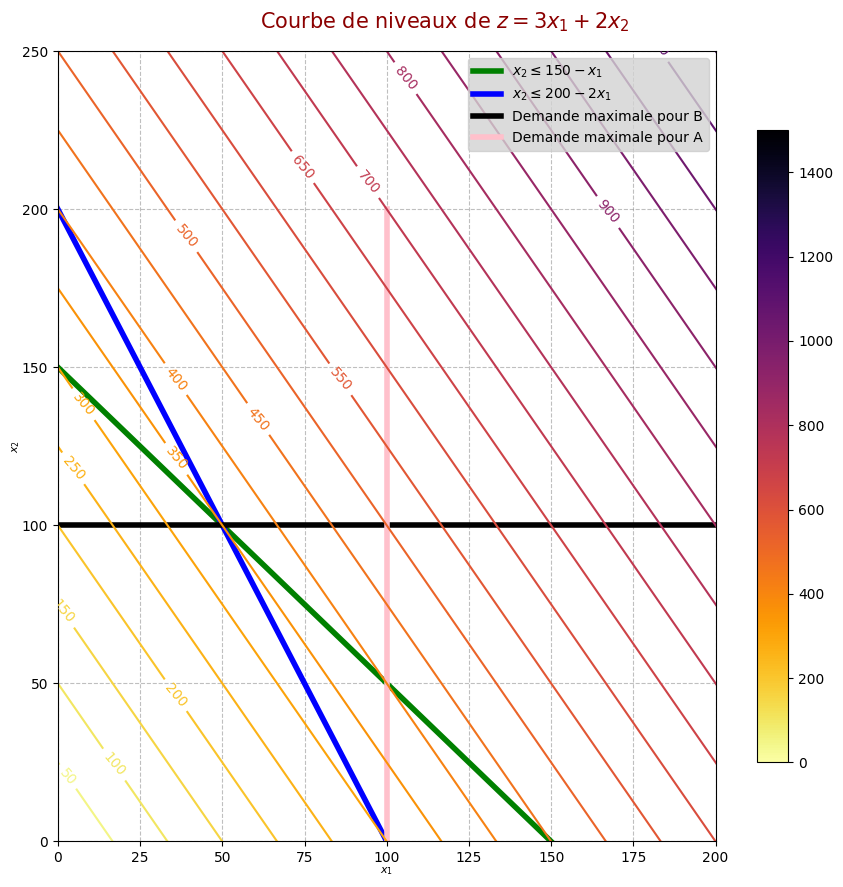

In [3]:
sommet_1 = [0,150]
sommet_2 = [150,0]
sommet_3 = [0,100]
sommet_4 = [200,0]

sommet_x2_max2 = [100,100]
sommet_x2_max1 = [0,200]

sommet_x1_max1 = [100,100]
sommet_x1_max2 = [0,200]

fig,ax = plt.subplots(ncols=1,nrows=1,figsize = (9,9))

ax.plot(sommet_1,sommet_2,label = f'$x_{2} \\leq 150 - x_{1}$',color = 'green' ,lw = 4)
ax.plot(sommet_3,sommet_4,label = f'$x_{2} \\leq 200 - 2x_{1}$',color = 'blue',lw = 4)
ax.plot(sommet_x2_max1,sommet_x2_max2,color = 'black',lw = 4,label='Demande maximale pour B')
ax.plot(sommet_x1_max1,sommet_x1_max2,color = 'pink',lw = 4,label='Demande maximale pour A')


ax.set_xlim(0,200)
ax.set_ylim(0,250)

x_graph = np.linspace(0,300,1000)
y_graph = np.linspace(0,300,1000)

xx,yy= np.meshgrid(x_graph,y_graph)
ff = 3*xx + 2*yy

color_niv = plt.get_cmap('inferno')
contour = ax.contour(xx,yy,ff,np.arange(ff.min(),ff.max(),50),cmap = color_niv.reversed())


ax.clabel(contour, inline=1, fontsize=10)


norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
sm1 = plt.cm.ScalarMappable(cmap=color_niv.reversed(), norm=norm1)

sm1.set_array([])
sm1.set_clim(ff.min(), ff.max())

fig.colorbar(sm1, ax=ax, shrink=0.8)


mon_theme(fig,ax,show_grid=True,show_legende_a_droite=False,
          loc_si_legende_interieure=1,
          marge_droite_graph=1,legend_fontsize=10,
          titre='Courbe de niveaux de $z = 3x_{1} + 2x_{2}$',
          xlabel='$x_{1}$',ylabel='$x_{2}$',
          xlabelsize=8,ylabelsize=8)



<span style="color: #8B6508; font-size: 20px;">3. Mettre le problème sous forme normal.</span>

Le programme sous forme normale à résoudre est le suivant :

$\begin{align} 
P =  \begin{cases} 
\max z_{\substack{\{x_{1},x_{2},x_{3},x_{4},x_{5},x_{6}\}}}(x_{1},x_{2}) = 3x_{1} + 2x_{2} \\ \\
\text{\textbf{sous les contraintes :}} \\
x_{1} + x_{3} = 100, \ x_{2}+x_{4} = 100 \\ 
2x_{1} + x_{2} + x_{5} = 200 \\ 
x_{1} + x_{2} + x_{6} = 150  
\end{cases}
\end{align}$

In [4]:
Fonction = [-3,-2]

bound = 2*[(0,100)]

coef_contrainte = np.array([[2,1],
                           [1,1]])

Second_membre = np.array([200,150])



<span style="color: #8B6508; font-size: 20px;">4. Résoudre le problème en utilisant `so.linprog`</span>

In [5]:
result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds = bound)

In [6]:
print(f'z atteint sa valeur maximale au point (x1*,x2*) = {result.x}.\nCette valeur est {-result.fun}.')
print(f"Ainsi l'entreprise va vendre {result.x[0]} voitures du modèle A et {result.x[1]} voiture du modèle B.\nSon bénéfice sera de {-result.fun*1000}€")

z atteint sa valeur maximale au point (x1*,x2*) = [ 50. 100.].
Cette valeur est 350.0.
Ainsi l'entreprise va vendre 50.0 voitures du modèle A et 100.0 voiture du modèle B.
Son bénéfice sera de 350000.0€


<span style="color: #8B6508; font-size: 20px;">5 La demande en modèle B s'effondre pour. On ne peux en écouler qu'un maximum de 50 par mois. Résoudre le problème.</span>

In [7]:
Fonction = [-3,-2]

bound = [(0,100),(0,50)]

coef_contrainte = np.array([[2,1],
                           [1,1]])

Second_membre = np.array([200,150])

In [8]:
result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)

In [9]:
print(f'z atteint sa valeur maximale au point (x1*,x2*) = {result.x}.\nCette valeur est {-result.fun}.')
print(f"Ainsi l'entreprise va vendre {result.x[0]} voitures du modèle A et {result.x[1]} voiture du modèle B.\nSon bénéfice sera de {-result.fun*1000}€")

z atteint sa valeur maximale au point (x1*,x2*) = [75. 50.].
Cette valeur est 325.0.
Ainsi l'entreprise va vendre 75.0 voitures du modèle A et 50.0 voiture du modèle B.
Son bénéfice sera de 325000.0€


On remarque que sans les contraintes, l'entreprise n'hésiterait pas à ne produire que du modèle A, cependant la présence des contraintes ainsi que la demande maximale de B le force à produire autant de voiture du modèle B que ses contraintes ne le permettent.

<span style="color: #8B6508; font-size: 20px;">6. Faire une analyse détaillée du problème en fonction d'un maximum du modèle B de 
$x_{max}∈
[
0
,
100
]$
.</span>

In [10]:
def introduction(x_max):

    Fonction = [-3,-2]

    bound = [(0,100),(0,x_max)]

    coef_contrainte = np.array([[2,1],
                           [1,1]])
    Second_membre = np.array([200,150])

    result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)

    print(f'z atteint sa valeur maximale au point (x1*,x2*) = {result.x}.\nCette valeur est {-result.fun}.')
    print(f"Ainsi l'entreprise va vendre {result.x[0]} voitures du modèle A et\n{result.x[1]} voiture du modèle B.\nSon bénéfice sera de {-result.fun*1000}€")

    sommet_1 = [0,150]
    sommet_2 = [150,0]
    sommet_3 = [0,100]
    sommet_4 = [200,0]
    

    sommet_x2_max2 = [x_max,x_max]
    sommet_x2_max1 = [0,200]

    sommet_x1_max1 = [100,100]
    sommet_x1_max2 = [0,200]

    fig,ax = plt.subplots(ncols=1,nrows=1,figsize = (9,9))

    ax.plot(sommet_1,sommet_2,label = f'$x_{2} \\leq 150 - x_{1}$',color = 'green' ,lw = 4)
    ax.plot(sommet_3,sommet_4,label = f'$x_{2} \\leq 200 - 2x_{1}$',color = 'blue',lw = 4)
    ax.plot(sommet_x2_max1,sommet_x2_max2,color = 'black',lw = 4,label='Demande maximale pour B')
    ax.plot(sommet_x1_max1,sommet_x1_max2,color = 'pink',lw = 4,label='Demande maximale pour A')

    ax.set_xlim(0,200)
    ax.set_ylim(0,200)
    
    ax.plot(result.x[0],result.x[1],'ob',lw = 4,color = 'red',label='Max de z sous les contraintes')

    x_graph = np.linspace(0,300,1000)
    y_graph = np.linspace(0,300,1000)

    xx,yy= np.meshgrid(x_graph,y_graph)
    ff = 3*xx + 2*yy

    color_niv = plt.get_cmap('inferno')
    contour = ax.contour(xx,yy,ff,np.arange(ff.min(),ff.max(),50),cmap = color_niv.reversed())


    ax.clabel(contour, inline=1, fontsize=10)


    norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
    sm1 = plt.cm.ScalarMappable(cmap=color_niv.reversed(), norm=norm1)

    sm1.set_array([])
    sm1.set_clim(ff.min(), ff.max())

    fig.colorbar(sm1, ax=ax, shrink=0.8)


    mon_theme(fig,ax,show_grid=True,show_legende_a_droite=False,
            loc_si_legende_interieure=1,
            marge_droite_graph=1,legend_fontsize=10,
            titre='Courbe de niveaux de $z = 3x_{1} + 2x_{2}$',
            xlabel='$x_{1}$',ylabel='$x_{2}$',
            xlabelsize=8,ylabelsize=8)

In [12]:
widgt_intro = interactive(introduction,x_max  =(0,100,1))
widgt_intro

On remarque que 3 contraintes sont saturées lorsque la demande maximale pour le modèle B est de 100, cependant, pour toute demande maximale inférieure à 100, seule deux contraintes sont saturées. On ressent que le temps de construction des modèles A est très contraignantes pour l'entreprise qui pourrait encore augmenter ses bénéfices si ce temps de construction pouvait diminuer

# B - Optimisation non-linéaire

<span style="color: #8B6508; font-size: 20px;">1. Poser clairement le problème et le résoudre avec les contraintes de la question 1 de l'introduction.
On pensera notamment à une représentation graphique.</span>

La fonction de bénéfice change étant donné que les prix sont devenus dégressifs. Elle devient

In [11]:
def f(X):
    return -(3*(1-(X[0]/300))*X[0] + 2*(1-(X[1]/200))*X[1])

Les contraintes n'ont pas changé :

In [12]:
def g1(X):
    return 200 - 2*X[0]-X[1]

def g2(X):
    return 150 - X[0] -X[1]

bound = 2*[(0,100)]

cons = [{'type':'ineq','fun':g1},
        {'type':'ineq','fun':g2}]


In [13]:
cond_initiale = [(i,j) for i,j in zip([0,5,7,50,100,5,6,70,6,1],[6,70,6,5,100,50,7,5,0,1])]

val_f = []
candidat_max = []

for i in cond_initiale:
    result = so.minimize(f,x0=(0,0),constraints=cons,bounds=bound)
    if result.success:
        val_f.append(-result.fun)
        candidat_max.append(result.x)

point_max = []
for k in range(len(val_f)):
    if val_f[k] == max(val_f):
        point_max.append(candidat_max[k])
        break

print(f'Avec cette nouvelle fonction de bénéfice, f atteint sa valeur maximale : {round(max(val_f))}\n au point {point_max}')
print(f"Ainsi l'entreprise fera un bénéfice maximale de {round(max(val_f))*1000}€ en vendant {round(point_max[0][0])} voitures du modèle A et {round(point_max[0][1])} voitures du modèle B")


Avec cette nouvelle fonction de bénéfice, f atteint sa valeur maximale : 245
 au point [array([70.00002473, 59.99995054])]
Ainsi l'entreprise fera un bénéfice maximale de 245000€ en vendant 70 voitures du modèle A et 60 voitures du modèle B


On remarque que cette nouvelle fonction de bénéfice est moins profitable à l'entreprise, c'est la conséquence des prix régressifs

Graphiquement :

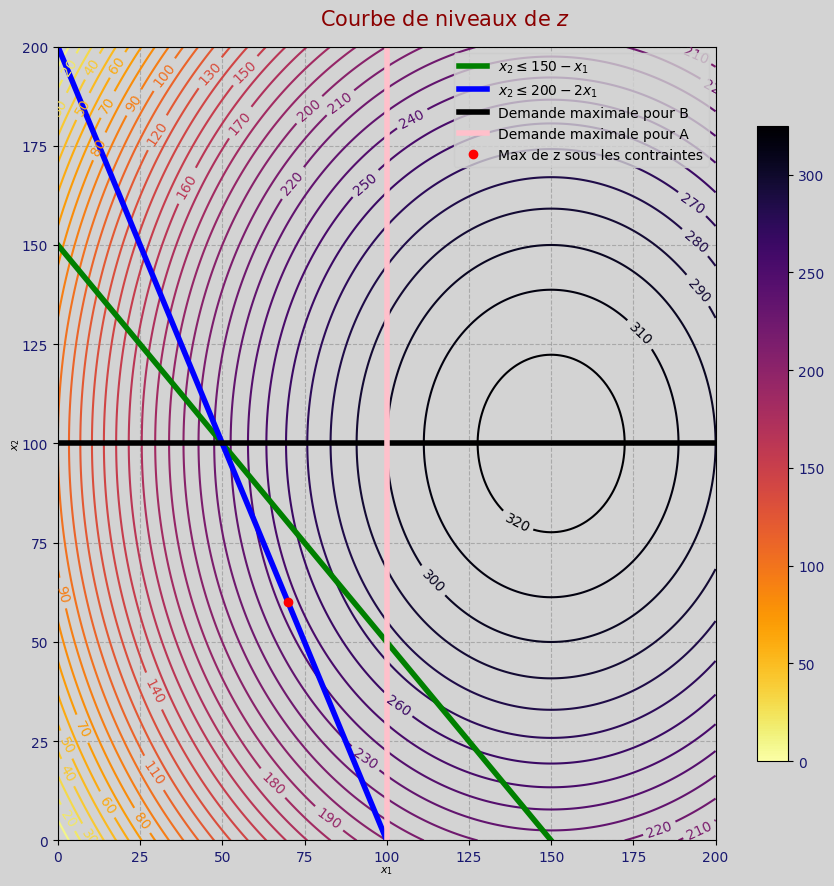

In [14]:


x_graph = np.linspace(0,200,200)
y_graph = np.linspace(0,200,200)

xx,yy = np.meshgrid(x_graph,y_graph)

ff = -f((xx,yy))

fig,ax = plt.subplots(nrows=1,ncols=1)

color_niv = plt.get_cmap('inferno')
contour = ax.contour(xx,yy,ff,np.arange(ff.min(),ff.max(),10),cmap = color_niv.reversed())


ax.clabel(contour, inline=1, fontsize=10)


norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
sm1 = plt.cm.ScalarMappable(cmap=color_niv.reversed(), norm=norm1)

sm1.set_array([])
sm1.set_clim(ff.min(), ff.max())

fig.colorbar(sm1, ax=ax, shrink=0.8)



sommet_1 = [0,150]
sommet_2 = [150,0]
sommet_3 = [0,100]
sommet_4 = [200,0]


sommet_x2_max2 = [100,100]
sommet_x2_max1 = [0,200]

sommet_x1_max1 = [100,100]
sommet_x1_max2 = [0,200]



ax.plot(sommet_1,sommet_2,label = f'$x_{2} \leq 150 - x_{1}$',color = 'green' ,lw = 4)
ax.plot(sommet_3,sommet_4,label = f'$x_{2} \leq 200 - 2x_{1}$',color = 'blue',lw = 4)
ax.plot(sommet_x2_max1,sommet_x2_max2,color = 'black',lw = 4,label='Demande maximale pour B')
ax.plot(sommet_x1_max1,sommet_x1_max2,color = 'pink',lw = 4,label='Demande maximale pour A')

ax.plot(result.x[0],result.x[1],'ob',lw = 10,color = 'red',label='Max de z sous les contraintes')


mon_theme(fig,ax,show_grid=True,show_legende_a_droite=False,
          loc_si_legende_interieure=1,
          marge_droite_graph=1,legend_fontsize=10,
          titre='Courbe de niveaux de $z$',
          xlabel='$x_{1}$',ylabel='$x_{2}$',
          xlabelsize=8,ylabelsize=8)


1 seule contrainte est saturée pour ce nouveau problème

<span style="color: #8B6508; font-size: 20px;">2. Faire une analyse détaillée du problème en fonction d'un maximum du modèle B de 
$x_{max}
∈
[
0
,
100
]$
.</span>

In [15]:

def f(X):
    return -(3*(1-(X[0]/300))*X[0] + 2*(1-(X[1]/200))*X[1])

def g1(X):
    return 200 - 2*X[0]-X[1]

def g2(X):
    return 150 - X[0] -X[1]


def opti_non_linéaire(x_max):
    bound = [(0,100),(0,x_max)]

    cons = [{'type':'ineq','fun':g1},
            {'type':'ineq','fun':g2}]


    cond_initiale = [(i,j) for i,j in zip([0,5,7,50,100,5,6,70,6,1],[6,70,6,5,100,50,7,5,0,1])]

    val_f = []
    candidat_max = []

    for i in cond_initiale:
        result = so.minimize(f,x0=(0,0),constraints=cons,bounds=bound)
        if result.success:
            val_f.append(-result.fun)
            candidat_max.append(result.x)

    point_max = []
    for k in range(len(val_f)):
        if val_f[k] == max(val_f):
            point_max.append(candidat_max[k])
            break

    print(f'Avec cette nouvelle fonction de bénéfice, f atteint sa valeur maximale : {round(max(val_f))}\n au point {point_max}')
    print(f"Ainsi l'entreprise fera un bénéfice maximale de {round(max(val_f))*1000} en vendant {round(point_max[0][0])} voitures du modèle A et {round(point_max[0][1])} voitures du modèle B")



    x_graph = np.linspace(0,200,200)
    y_graph = np.linspace(0,200,200)

    xx,yy = np.meshgrid(x_graph,y_graph)

    ff = -f((xx,yy))

    fig,ax = plt.subplots(nrows=1,ncols=1)

    color_niv = plt.get_cmap('inferno')
    contour = ax.contour(xx,yy,ff,np.arange(ff.min(),ff.max(),10),cmap = color_niv.reversed())


    ax.clabel(contour, inline=1, fontsize=10)


    norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
    sm1 = plt.cm.ScalarMappable(cmap=color_niv.reversed(), norm=norm1)

    sm1.set_array([])
    sm1.set_clim(ff.min(), ff.max())

    fig.colorbar(sm1, ax=ax, shrink=0.8)



    sommet_1 = [0,150]
    sommet_2 = [150,0]
    sommet_3 = [0,100]
    sommet_4 = [200,0]


    sommet_x2_max2 = [x_max,x_max]
    sommet_x2_max1 = [0,200]

    sommet_x1_max1 = [100,100]
    sommet_x1_max2 = [0,200]



    ax.plot(sommet_1,sommet_2,label = f'$x_{2} \leq 150 - x_{1}$',color = 'green' ,lw = 4)
    ax.plot(sommet_3,sommet_4,label = f'$x_{2} \leq 200 - 2x_{1}$',color = 'blue',lw = 4)
    ax.plot(sommet_x2_max1,sommet_x2_max2,color = 'black',lw = 4,label='Demande maximale pour B')
    ax.plot(sommet_x1_max1,sommet_x1_max2,color = 'pink',lw = 4,label='Demande maximale pour A')

    ax.plot(result.x[0],result.x[1],'ob',lw = 10,color = 'red',label='Max de z sous les contraintes')


    mon_theme(fig,ax,show_grid=True,show_legende_a_droite=False,
            loc_si_legende_interieure=1,
            marge_droite_graph=1,legend_fontsize=10,
            titre='Courbe de niveaux de $z$',
            xlabel='$x_{1}$',ylabel='$x_{2}$',
            xlabelsize=8,ylabelsize=8)

In [147]:
widgt_opti_non_linéaire = interactive(opti_non_linéaire,x_max = (0,100,1))
widgt_opti_non_linéaire

interactive(children=(IntSlider(value=50, description='x_max'), Output()), _dom_classes=('widget-interact',))

Lorsque la demande maximale pour le modèle B est nulle alors deux contraintes sont saturées car l'entreprise va vendre 100 voitures du modèle 1, mais dès que cette demande maximale est non nulle, alors 1 seule contrainte est saturée 

# C - Un modèle à 4 variables

On reprend la base de l'introduction : ignorez la partie B.

Un manageur propose de dessiner deux nouveaux modèles de luxes C et D.

- Les bénéfices unitaire de ces deux modèles sont de respectivement 5 000 et 10 000 €.

- La demande de ces modèles de luxe est assez limité et est de 30 unités au total (C+D).

- La demande mensuelle totale de voiture est toujours de 150.

- Le modèle C prend 5 heures de construction et le D en prend 8.

Ce modèle a la modélisation suivante :

In [16]:
Fonction = [-3,-2,-5,-10]

bound = 2*[(0,100)]+[(0,None)]+[(0,None)]

coef_contrainte = np.array([[2,1,5,8],
                           [1,1,1,1],
                           [0,0,1,1]])

Second_membre = np.array([200,150,30])



In [17]:
result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)


In [18]:
print(f'La valeur maximale de f est :{round(-result.fun)} atteinte au point {result.x}.')
print(f"Ainsi l'entreprise réalisera un bénéfice de {round(-result.fun)*1000}€ et produira {result.x[0]} voiture du modèle A\n{result.x[1]} voiture du modèle B,\n{result.x[2]} voiture du modèle C et \n{result.x[3]} voiture du modèle D "  )

La valeur maximale de f est :350 atteinte au point [ 50. 100.   0.  -0.].
Ainsi l'entreprise réalisera un bénéfice de 350000€ et produira 50.0 voiture du modèle A
100.0 voiture du modèle B,
0.0 voiture du modèle C et 
-0.0 voiture du modèle D 


Les contraintes de production empêchent l'entreprise de produire ces deux voitures de luxes, ainsi, son niveau de production optimale est identique à celui qu'il avait lorsqu'il ne comptait produire que les modèles A et B

<span style="color: #8B6508; font-size: 20px;">2. L'entreprise fait un effort et double sa disponibilité passant à 400 heures mensuelles. Résoudre le problème.</span>

In [19]:
Fonction = [-3,-2,-5,-10]

bound = 2*[(0,100)]+[(0,None)]+[(0,None)]

coef_contrainte = np.array([[2,1,5,8],
                           [1,1,1,1],
                           [0,0,1,1]])

Second_membre = np.array([400,150,30])


In [20]:
result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)


In [21]:
print(f'La valeur maximale de f est :{round(-result.fun)} atteinte au point {result.x}.')
print(f"Ainsi l'entreprise réalisera un bénéfice de {round(-result.fun)*1000}€ et produira {result.x[0]} voiture du modèle A\n{result.x[1]} voiture du modèle B,\n{result.x[2]} voiture du modèle C et \n{result.x[3]} voiture du modèle D "  )

La valeur maximale de f est :580 atteinte au point [40. 80.  0. 30.].
Ainsi l'entreprise réalisera un bénéfice de 580000€ et produira 40.00000000000006 voiture du modèle A
79.99999999999996 voiture du modèle B,
0.0 voiture du modèle C et 
29.999999999999993 voiture du modèle D 


Ce doublement de la disponibilité a permis à l'entreprise d'augmenter son bénéfice grâce à une plus grande diversification des produits, avec notamment des voitures de modèle standard A et B et 1 voiture de luxe avec le modèle D, cependant, la voiture C est longue à produire pour un bénéfice additionnelle tel que l'entreprise préfère ne pas en produire, mais il est possible que produire ce modèle lui soit profitable si elle augmente encore ses disponibilités.

<span style="color: #8B6508; font-size: 20px;">3. Etudier l'impact du temps de disponibilité de l'usine sur la stratégie de l'entreprise.</span>

In [22]:
def partieC(dispo):

    Fonction = [-3,-2,-5,-10]

    bound = 2*[(0,100)]+[(0,None)]+[(0,None)]

    coef_contrainte = np.array([[2,1,5,8],
                            [1,1,1,1],
                            [0,0,1,1]])

    Second_membre = np.array([dispo,150,30])

    result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)

    return result 

    

In [24]:
f_max = []
X_sol_A = []
X_sol_B = []
X_sol_C = []
X_sol_D = []
for D in range(0,1000,1):
    result = partieC(D)
    if result.success:
        f_max.append(round(-result.fun))
        X_sol_A.append(result.x[0])
        X_sol_B.append(result.x[1])
        X_sol_C.append(result.x[2])
        X_sol_D.append(result.x[3])

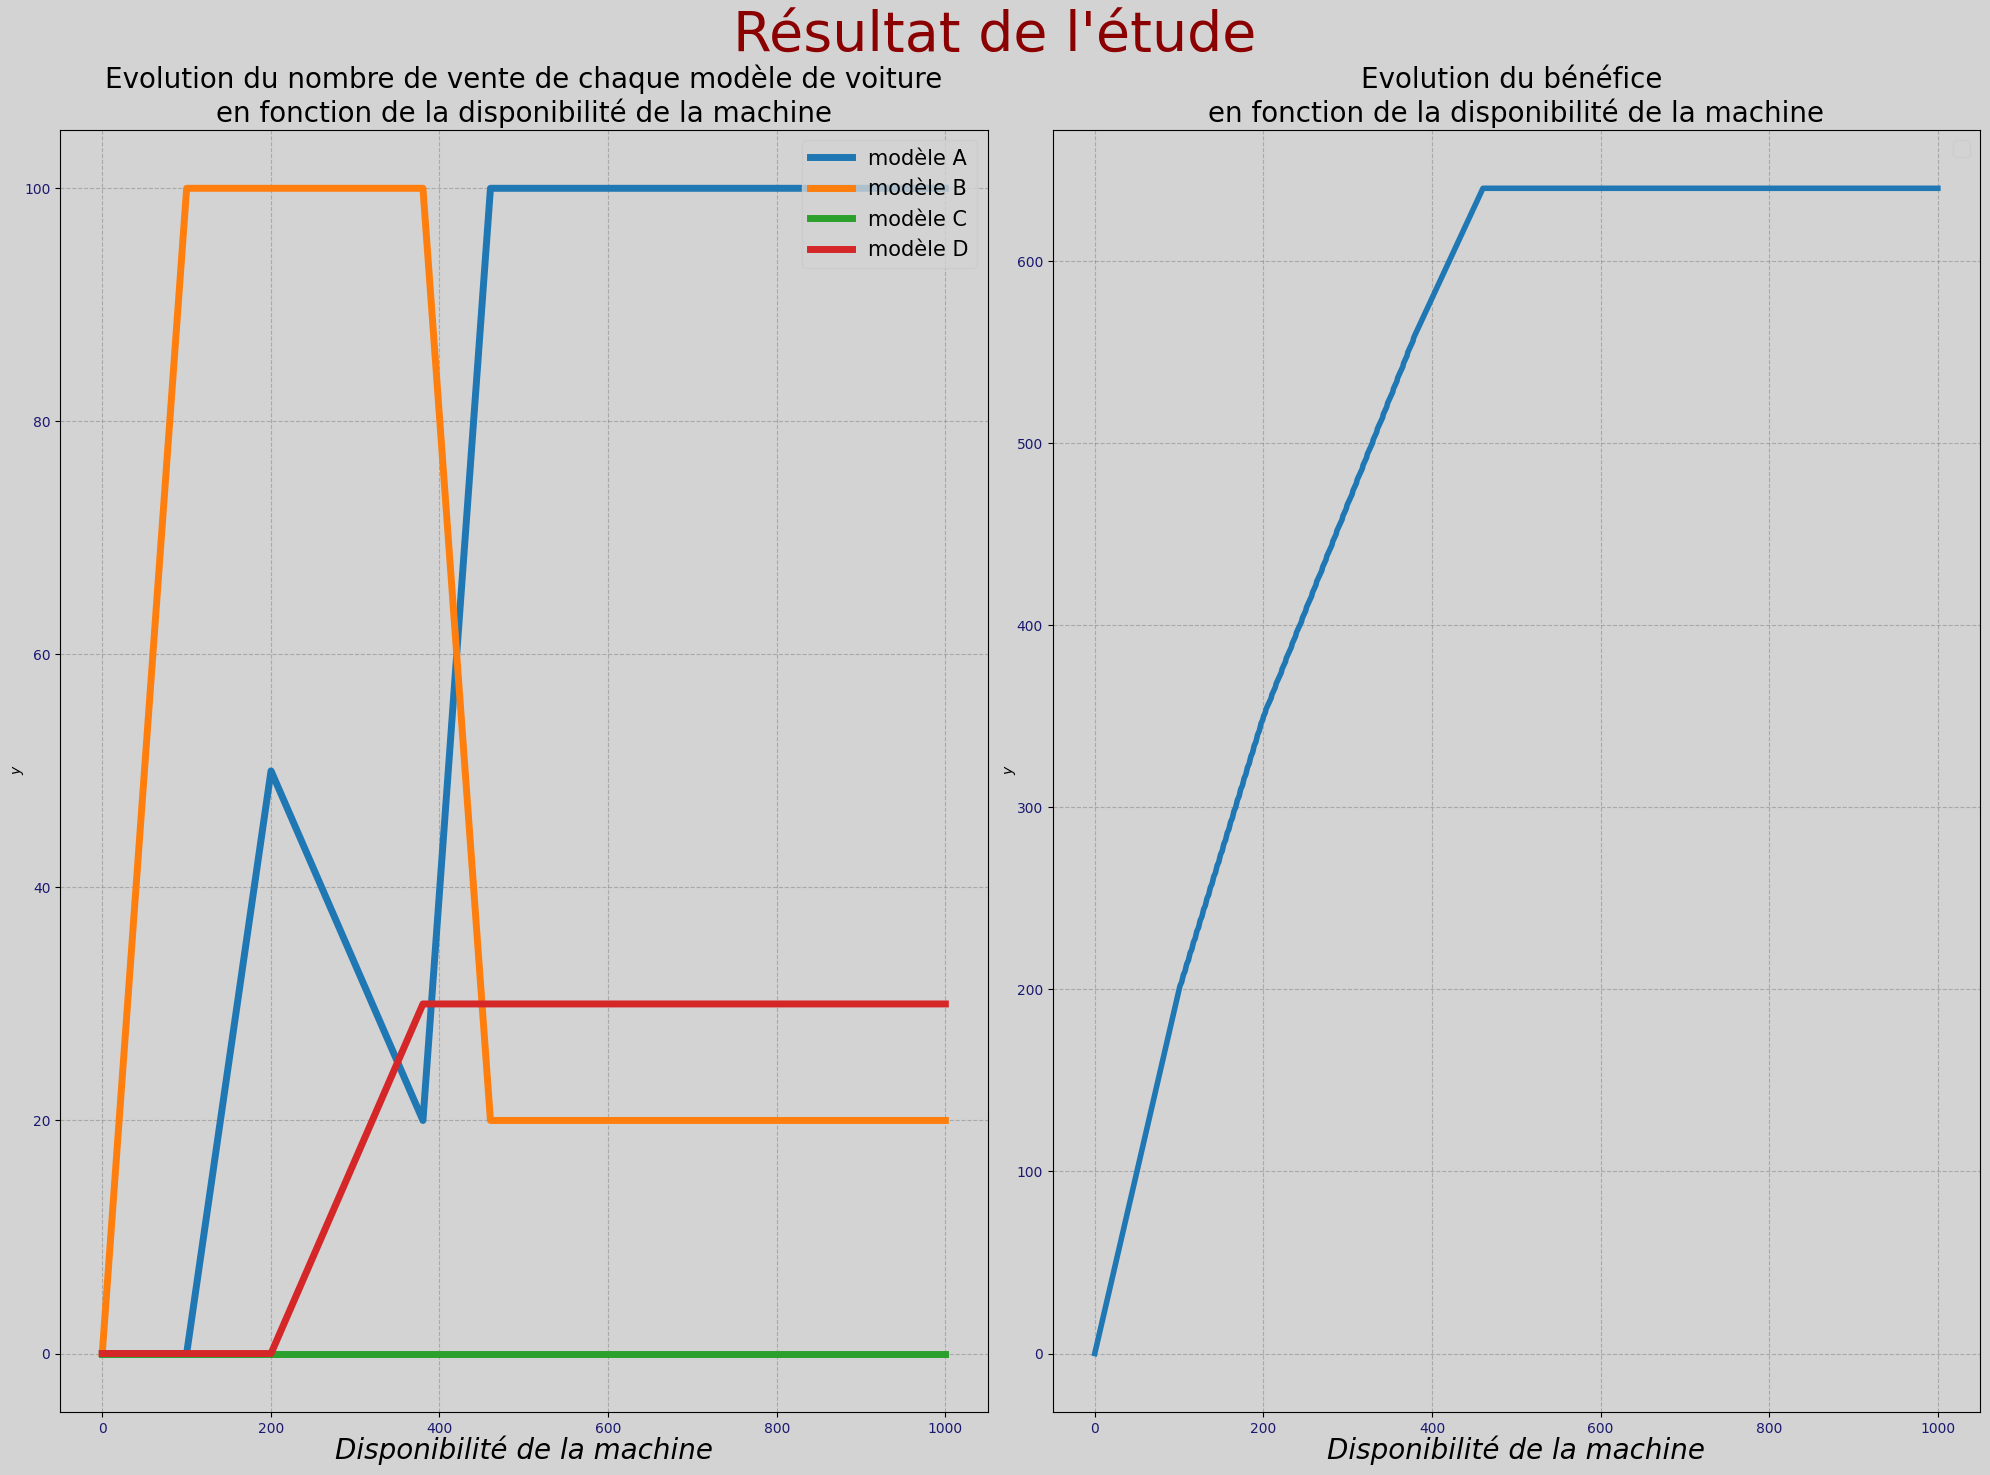

In [25]:
x_graph = np.linspace(0,1000,1000)

fig,ax = plt.subplots(ncols=2,nrows=1,figsize = (20,15))

ax[0].plot(x_graph,np.array(X_sol_A),lw=5,label ='modèle A')
ax[0].plot(x_graph,np.array(X_sol_B),lw=5,label = 'modèle B')
ax[0].plot(x_graph,np.array(X_sol_C),lw=5,label = 'modèle C')
ax[0].plot(x_graph,np.array(X_sol_D),lw=5,label = 'modèle D')
ax[0].set_title("Evolution du nombre de vente de chaque modèle de voiture\nen fonction de la disponibilité de la machine",size =20)

ax[1].plot(x_graph,f_max,lw=4)
ax[1].set_title('Evolution du bénéfice \nen fonction de la disponibilité de la machine',size = 20)

mon_theme(fig,ax,ncols=2,nrows=1,show_grid=True,show_legende_a_droite=False,
          loc_si_legende_interieure='upper right',
          xlabel='Disponibilité de la machine',
          titre="Résultat de l'étude",
          legend_fontsize=15,xlabelsize=20,titre_fontsize=40,
          marge_droite_graph=1)

On remarque qu'à partir d'une certaines disponibilités, l'entreprise n'augmente plus ses bénéfices.
L'entreprise ne produira jamais du modèle C trop coûteux en disponibilité pour un bénéfice additionnelle trop faible, on remarque aussi que l'entreprise produira du modèle D à partir d'une disponibilité supérieure à 200 heures.

# Partie D - Contraintes en matières premières

L'usine fait remarquer que les flux de matières premières sont tendus et demande de les prendre en compte. Elle fournie un document résumant les contraintes : contraintes_voitures.csv

<span style="color: #8B6508; font-size: 20px;">1. Résoudre le problème avec uniquement les modèles A et B de l'introduction. On fera notamment un graphique de la situation.</span>

In [28]:
data = pd.read_csv('contraintes_voitures.csv',sep=';',encoding="latin1")
data = data.set_index(' ')

In [29]:
data.head()

In [30]:

dataQ1 = data.loc[:,[k for k in data.columns if k in ['Modèle A','Modèle B','Limites des stocks mensuels']]]
dataQ1

In [31]:
Fonction = [-3,-2]

bound = 2*[(0,100)]

coef_contrainte = np.array([[2,1],
                           [1,1],
                           [2,1],
                           [0.2,0.2],
                           [1,1],
                           [2,2],
                           [1,1],
                           [0,0],
                           [1,1],
                           [2,2],
                           [0,0]])

Second_membre = np.array([200,150,125,55,300,100,60,50,100,220,30])

result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)

In [32]:
print(f'Avec ces nouvelles contraintes, f atteint sa valeur maximale\n{-round(result.fun)}\n au point {result.x}')
print(f"Ainsi, l'entreprise réalisera un bénéfice de {-round(result.fun)*1000}€\n en vendant {result.x[0]} voitures du modèle A et {result.x[1]} du modèle B")

Avec ces nouvelles contraintes, f atteint sa valeur maximale
150
 au point [50.  0.]
Ainsi, l'entreprise réalisera un bénéfice de 150000€
 en vendant 50.0 voitures du modèle A et 0.0 du modèle B


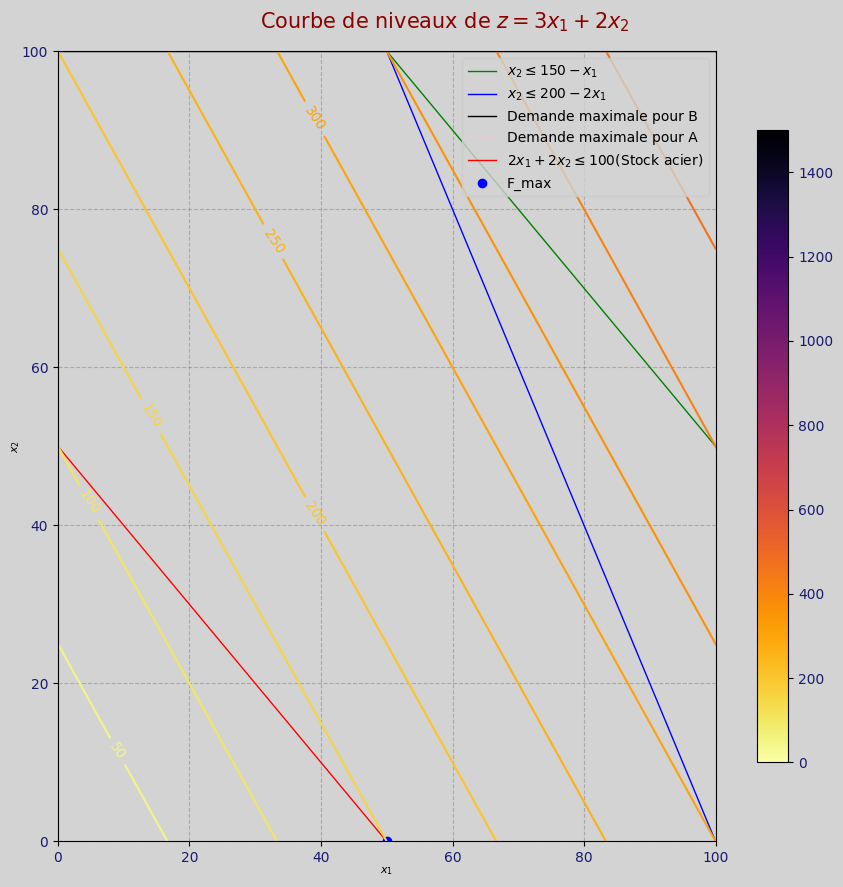

In [33]:
sommet_1 = [0,150]
sommet_2 = [150,0]
sommet_3 = [0,100]
sommet_4 = [200,0]

sommet_x2_max2 = [100,100]
sommet_x2_max1 = [0,200]

sommet_x1_max1 = [100,100]
sommet_x1_max2 = [0,200]

sommet_Acier_A = [0,50]
sommet_Acier_B = [50,0]

fig,ax = plt.subplots(ncols=1,nrows=1,figsize = (9,9))

ax.plot(sommet_1,sommet_2,label = f'$x_{2} \leq 150 - x_{1}$',color = 'green' ,lw = 1)
ax.plot(sommet_3,sommet_4,label = f'$x_{2} \leq 200 - 2x_{1}$',color = 'blue',lw = 1)
ax.plot(sommet_x2_max1,sommet_x2_max2,color = 'black',lw = 1,label='Demande maximale pour B')
ax.plot(sommet_x1_max1,sommet_x1_max2,color = 'pink',lw = 1,label='Demande maximale pour A')

ax.plot(sommet_Acier_A,sommet_Acier_B,color = 'red',lw = 1,label='$2x_{1} + 2x_{2} \leq 100 $(Stock acier)')

ax.plot(result.x[0],result.x[1],'ob',color = 'blue',label = 'F_max')

ax.set_xlim(0,100)
ax.set_ylim(0,100)

x_graph = np.linspace(0,300,1000)
y_graph = np.linspace(0,300,1000)

xx,yy= np.meshgrid(x_graph,y_graph)
ff = 3*xx + 2*yy

color_niv = plt.get_cmap('inferno')
contour = ax.contour(xx,yy,ff,np.arange(ff.min(),ff.max(),50),cmap = color_niv.reversed())


ax.clabel(contour, inline=1, fontsize=10)


norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
sm1 = plt.cm.ScalarMappable(cmap=color_niv.reversed(), norm=norm1)

sm1.set_array([])
sm1.set_clim(ff.min(), ff.max())

fig.colorbar(sm1, ax=ax, shrink=0.8)


mon_theme(fig,ax,show_grid=True,show_legende_a_droite=False,
          loc_si_legende_interieure=1,
          marge_droite_graph=1,legend_fontsize=10,
          titre='Courbe de niveaux de $z = 3x_{1} + 2x_{2}$',
          xlabel='$x_{1}$',ylabel='$x_{2}$',
          xlabelsize=8,ylabelsize=8)

On remarque que le stock d'acier influe grandement sur les niveaux de production de l'entreprise. 

In [34]:
def partieD1(stock_acier):
    Fonction = [-3,-2]

    bound = 2*[(0,100)]

    coef_contrainte = np.array([[2,1],
                            [1,1],
                            [2,1],
                            [0.2,0.2],
                            [1,1],
                            [2,2],
                            [1,1],
                            [0,0],
                            [1,1],
                            [2,2],
                            [0,0]])

    Second_membre = np.array([200,150,125,55,300,stock_acier,60,50,100,220,30])

    result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)

    print(f'Avec ces nouvelles contraintes, f atteint sa valeur maximale\n{-round(result.fun)}\n au point {result.x}')
    print(f"Ainsi, l'entreprise réalisera un bénéfice de {-round(result.fun)*1000}€\n en vendant {result.x[0]} voitures du modèle A et {result.x[1]} du modèle B")
    
    sommet_1 = [0,150]
    sommet_2 = [150,0]
    sommet_3 = [0,100]
    sommet_4 = [200,0]

    sommet_x2_max2 = [100,100]
    sommet_x2_max1 = [0,200]

    sommet_x1_max1 = [100,100]
    sommet_x1_max2 = [0,200]

    sommet_Acier_A = [0,stock_acier/2]
    sommet_Acier_B = [stock_acier/2,0]

    fig,ax = plt.subplots(ncols=1,nrows=1,figsize = (9,9))

    ax.plot(sommet_1,sommet_2,label = f'$x_{2} \leq 150 - x_{1}$',color = 'green' ,lw = 1)
    ax.plot(sommet_3,sommet_4,label = f'$x_{2} \leq 200 - 2x_{1}$',color = 'blue',lw = 1)
    ax.plot(sommet_x2_max1,sommet_x2_max2,color = 'black',lw = 1,label='Demande maximale pour B')
    ax.plot(sommet_x1_max1,sommet_x1_max2,color = 'pink',lw = 1,label='Demande maximale pour A')

    ax.plot(sommet_Acier_A,sommet_Acier_B,color = 'red',lw = 1,label='$2x_{1} + 2x_{2} \leq {stock_acier} $(Stock acier)')

    ax.plot(result.x[0],result.x[1],'ob',color = 'blue',label = 'F_max')

    ax.set_xlim(0,100)
    ax.set_ylim(0,100)

    x_graph = np.linspace(0,300,1000)
    y_graph = np.linspace(0,300,1000)

    xx,yy= np.meshgrid(x_graph,y_graph)
    ff = 3*xx + 2*yy

    color_niv = plt.get_cmap('inferno')
    contour = ax.contour(xx,yy,ff,np.arange(ff.min(),ff.max(),50),cmap = color_niv.reversed())


    ax.clabel(contour, inline=1, fontsize=10)


    norm1 = Normalize(vmin=ff.min(), vmax=ff.max())
    sm1 = plt.cm.ScalarMappable(cmap=color_niv.reversed(), norm=norm1)

    sm1.set_array([])
    sm1.set_clim(ff.min(), ff.max())

    fig.colorbar(sm1, ax=ax, shrink=0.8)


    mon_theme(fig,ax,show_grid=True,show_legende_a_droite=False,
            loc_si_legende_interieure=1,
            marge_droite_graph=1,legend_fontsize=10,
            titre='Courbe de niveaux de $z = 3x_{1} + 2x_{2}$',
            xlabel='$x_{1}$',ylabel='$x_{2}$',
            xlabelsize=8,ylabelsize=8)

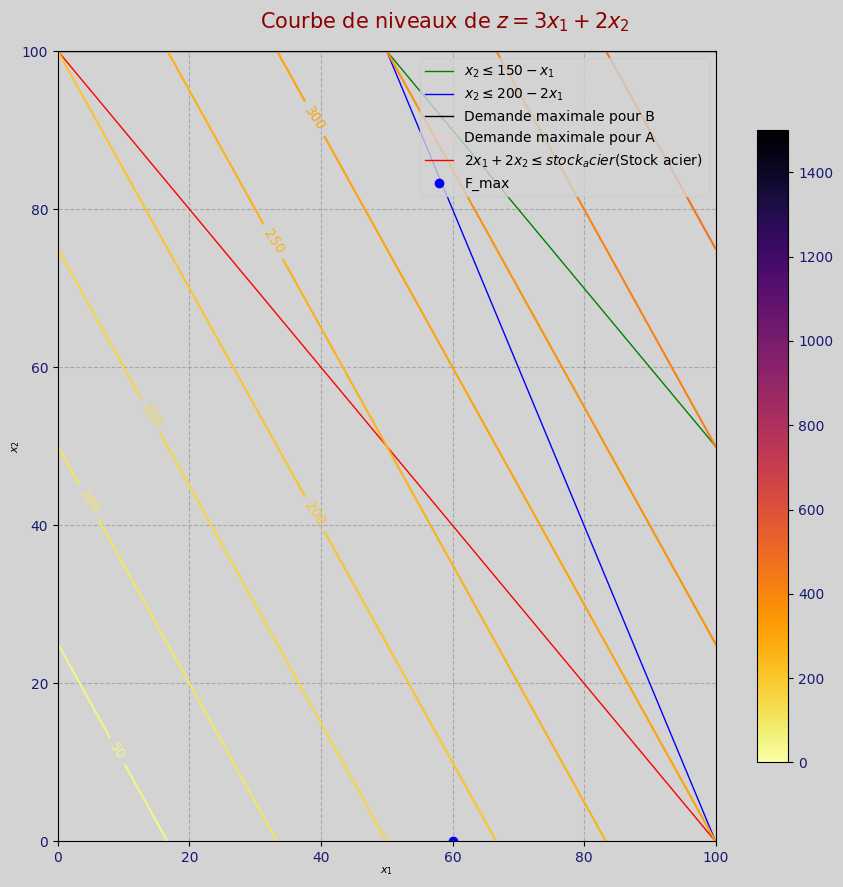

In [37]:
widgt_partieD1 = interactive(partieD1,stock_acier=(0,400,1))
widgt_partieD1

On remarque qu'à partir du moment où le stock en acier est supérieur à 120, alors la contrainte du stock d'acier n'est plus saturée et c'est une autre matière premère qui limite la production des voitures.

<span style="color: #8B6508; font-size: 20px;">2. Résoudre le problème avec toutes les contraintes ainsi que les modèles C et D de la partie B.</span>

In [38]:
data

In [39]:
Fonction = [-3,-2,-5,-10]

bound = 2*[(0,100)]+[(0,None)]+[(0,None)]


coef_contrainte = np.array([[2,1,5,8],
                           [1,1,1,1],
                           [0,0,1,1],
                           [2,1,4,2],
                           [0.2,0.2,0.5,1],
                           [1,1,2,2],
                           [2,2,1,2],
                           [1,1,1.5,0.8],
                           [0,0,2,2],
                           [1,1,1,1.2],
                           [2,2,1,1],
                           [0,0,1,1]])

Second_membre = np.array([200,150,30,125,55,300,100,60,50,100,220,30])

result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)


In [40]:
print('En incluant tous les modèles de voitures ainsi que les contraintes en matières premières')
print(f'z atteint sa valeur maximale {-round(result.fun)} au point {result.x}.')
print(f"Ainsi l'entreprise réalisera un bénéfice de {round(-result.fun)*1000}€ et produira environ {round(result.x[0])} voiture du modèle A\n{round(result.x[1])} voiture du modèle B,\n{round(result.x[2])} voiture du modèle C et \n{round(result.x[3])} voiture du modèle D "  )

En incluant tous les modèles de voitures ainsi que les contraintes en matières premières
z atteint sa valeur maximale 271 au point [ 0.         28.57142857  0.         21.42857143].
Ainsi l'entreprise réalisera un bénéfice de 271000€ et produira environ 0 voiture du modèle A
29 voiture du modèle B,
0 voiture du modèle C et 
21 voiture du modèle D 


<span style="color: #8B6508; font-size: 20px;">3. Résoudre le problème en complet en faisant varier les disponibilités de l'usine ainsi que la demande totale en véhicules.</span>

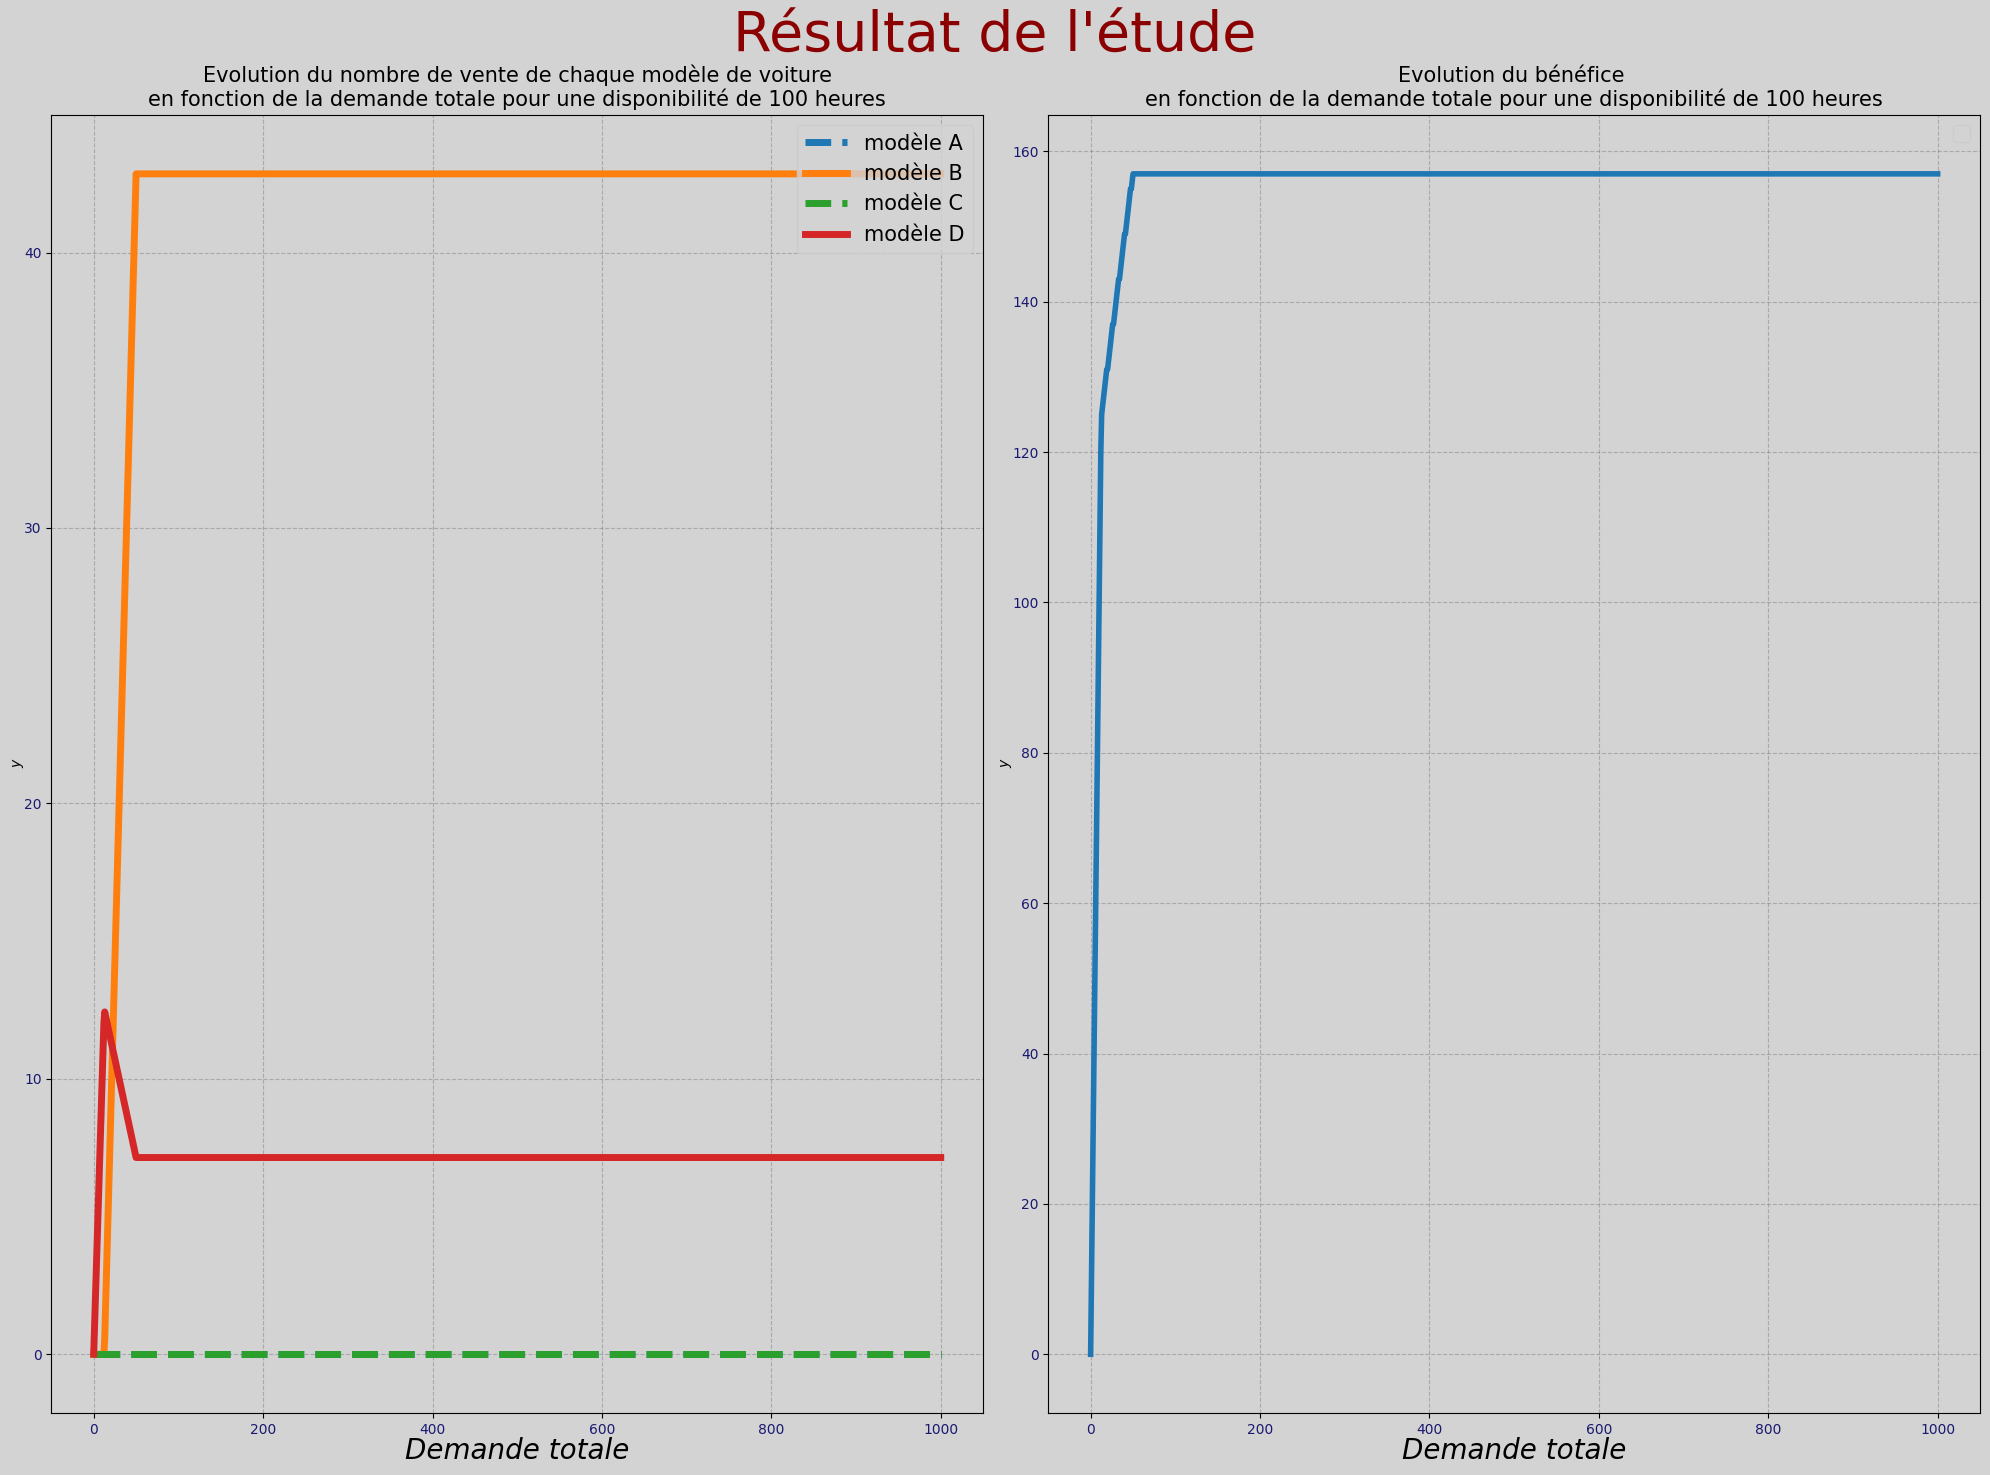

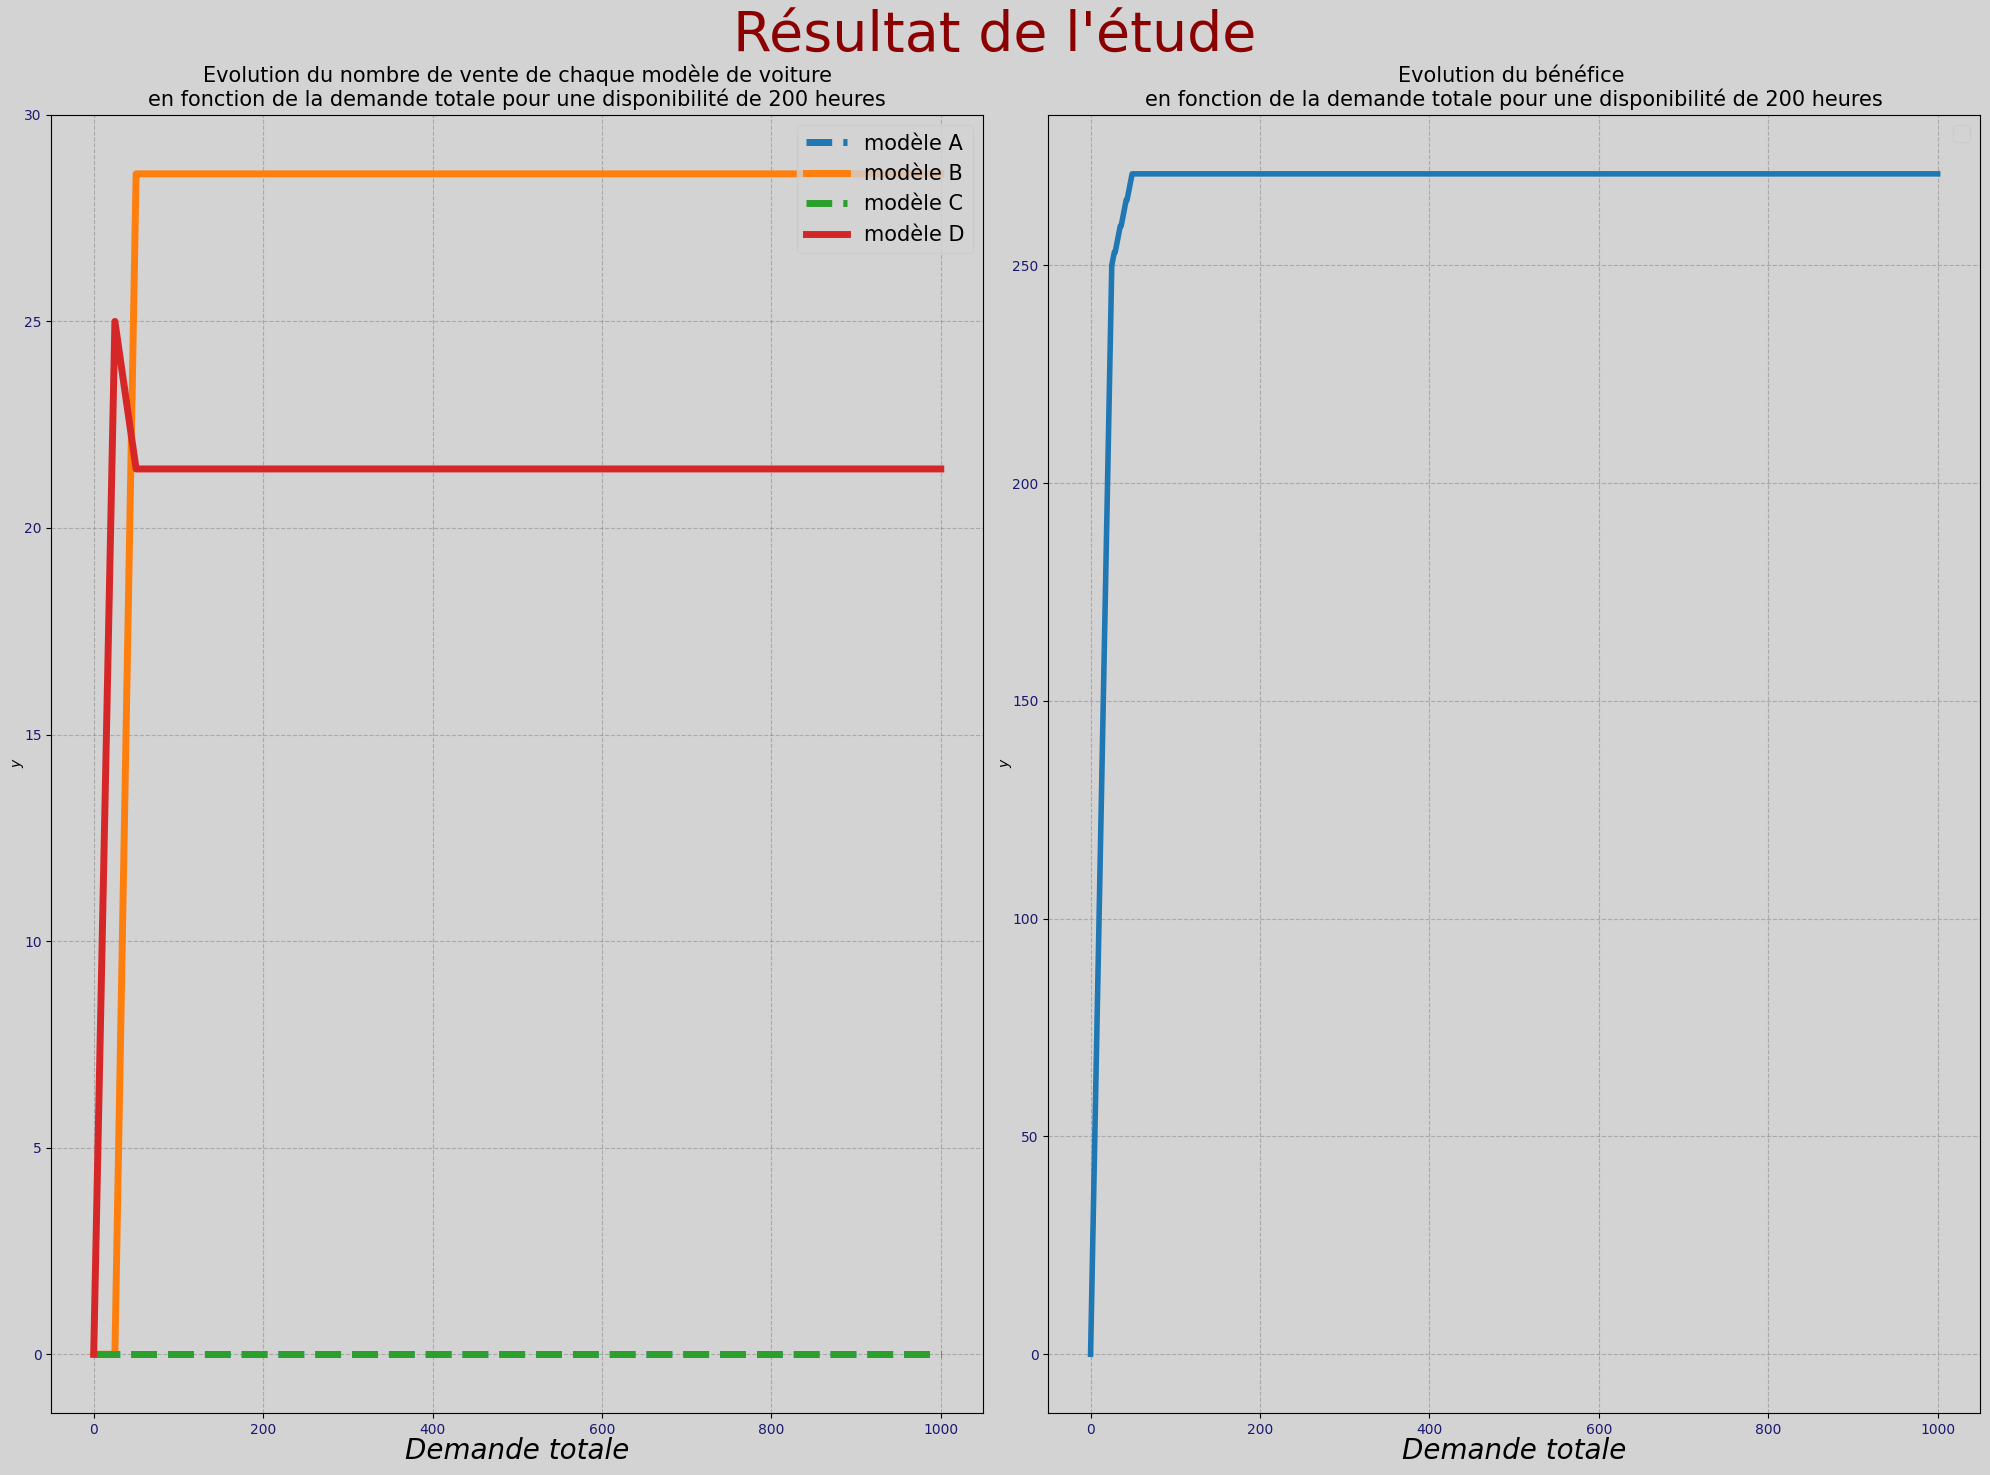

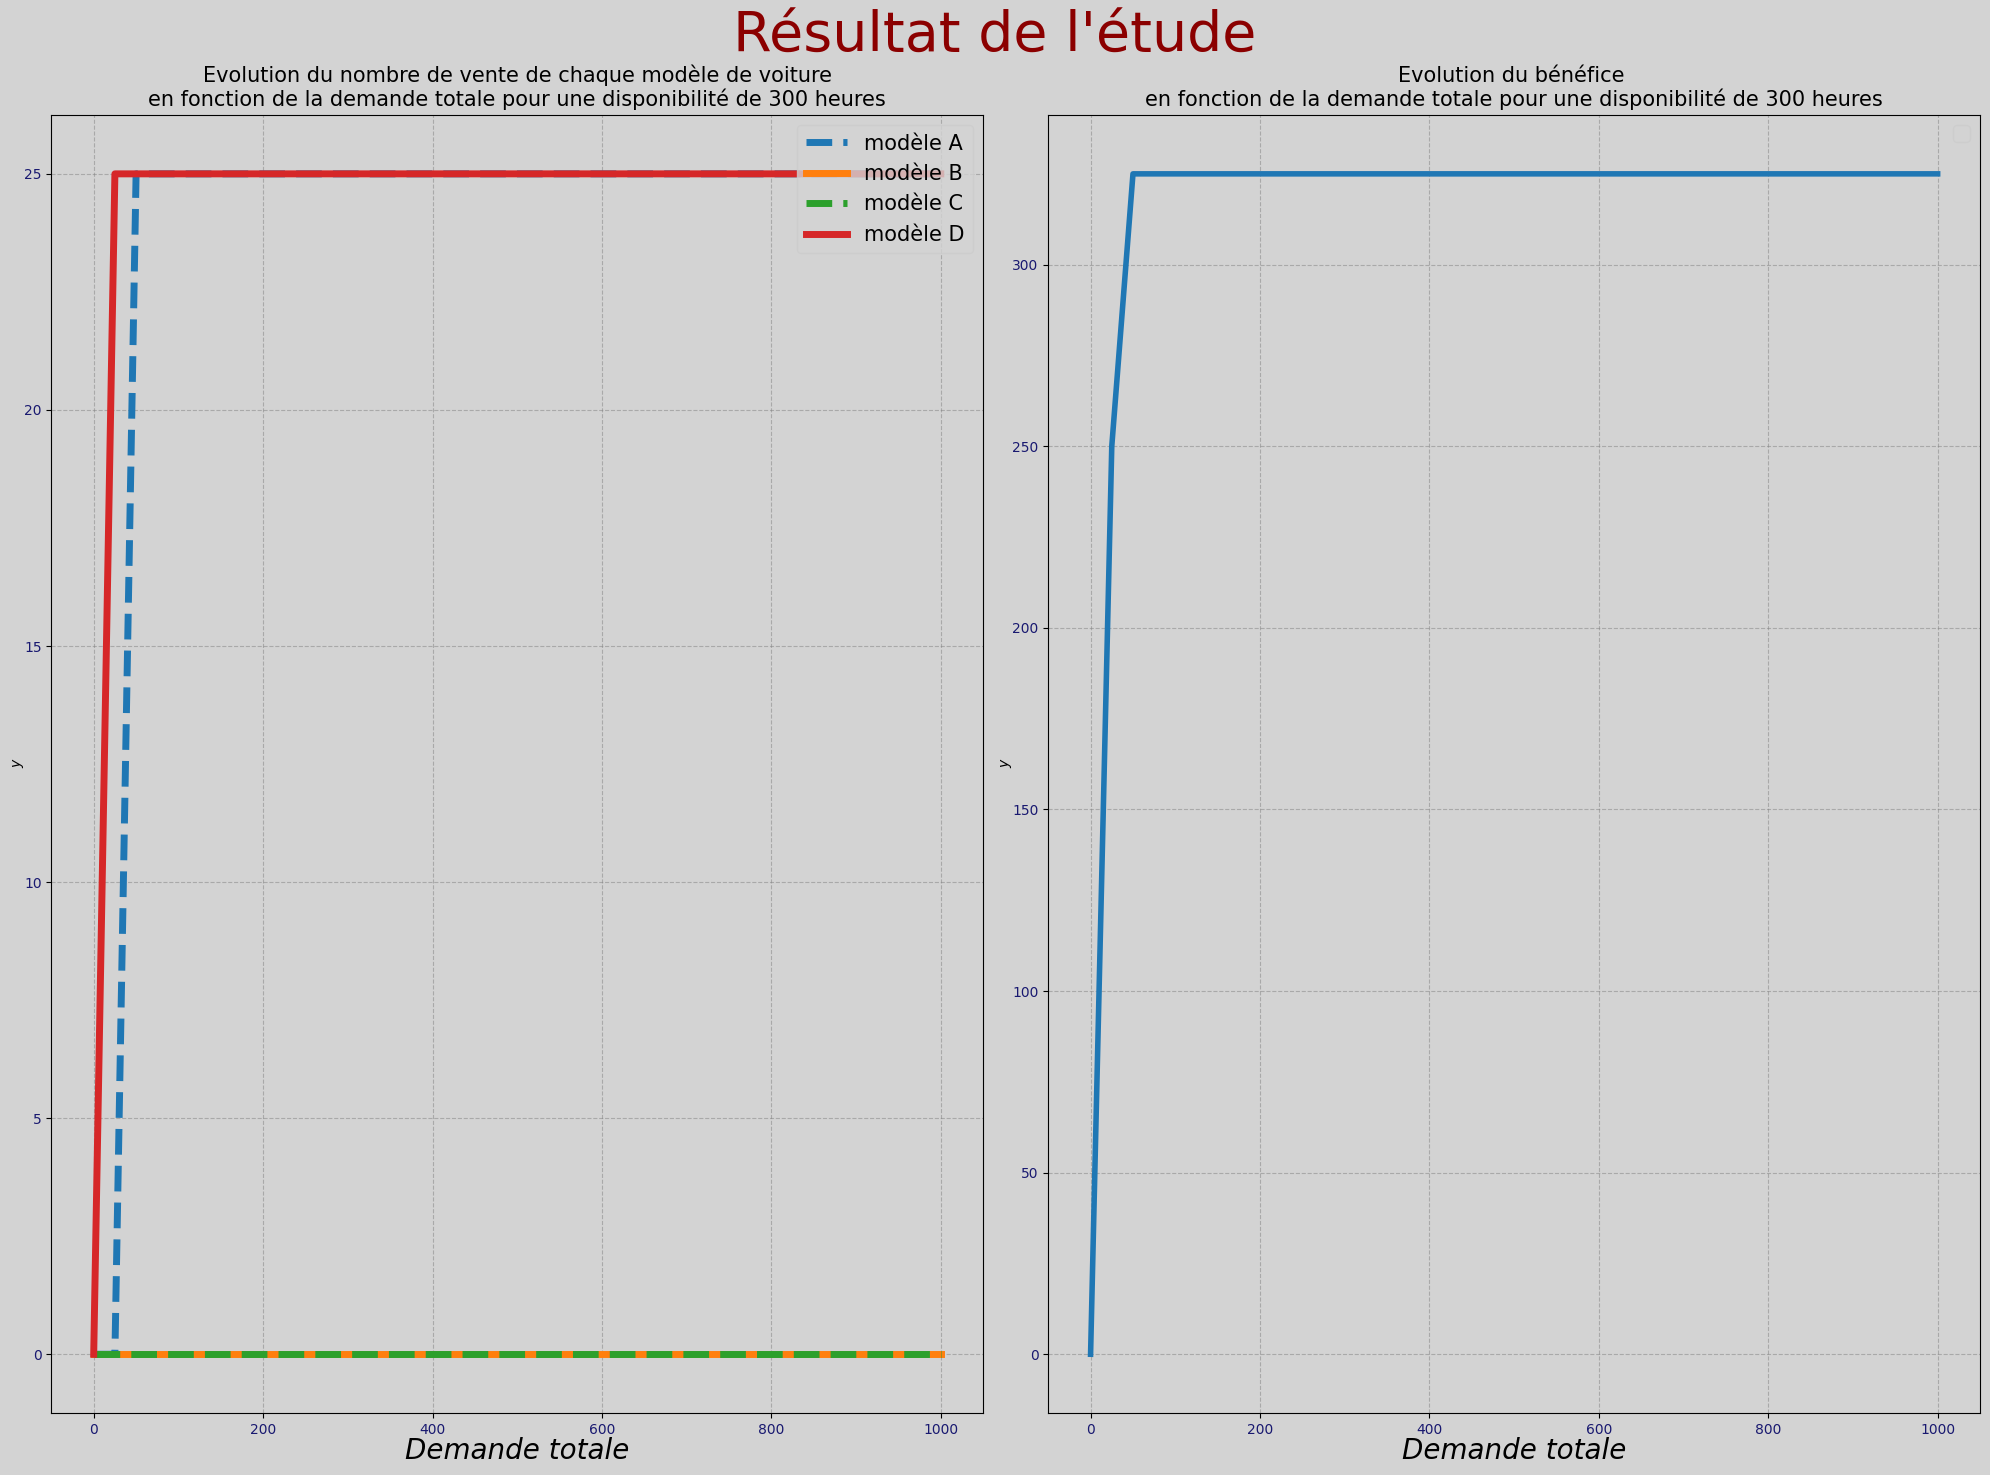

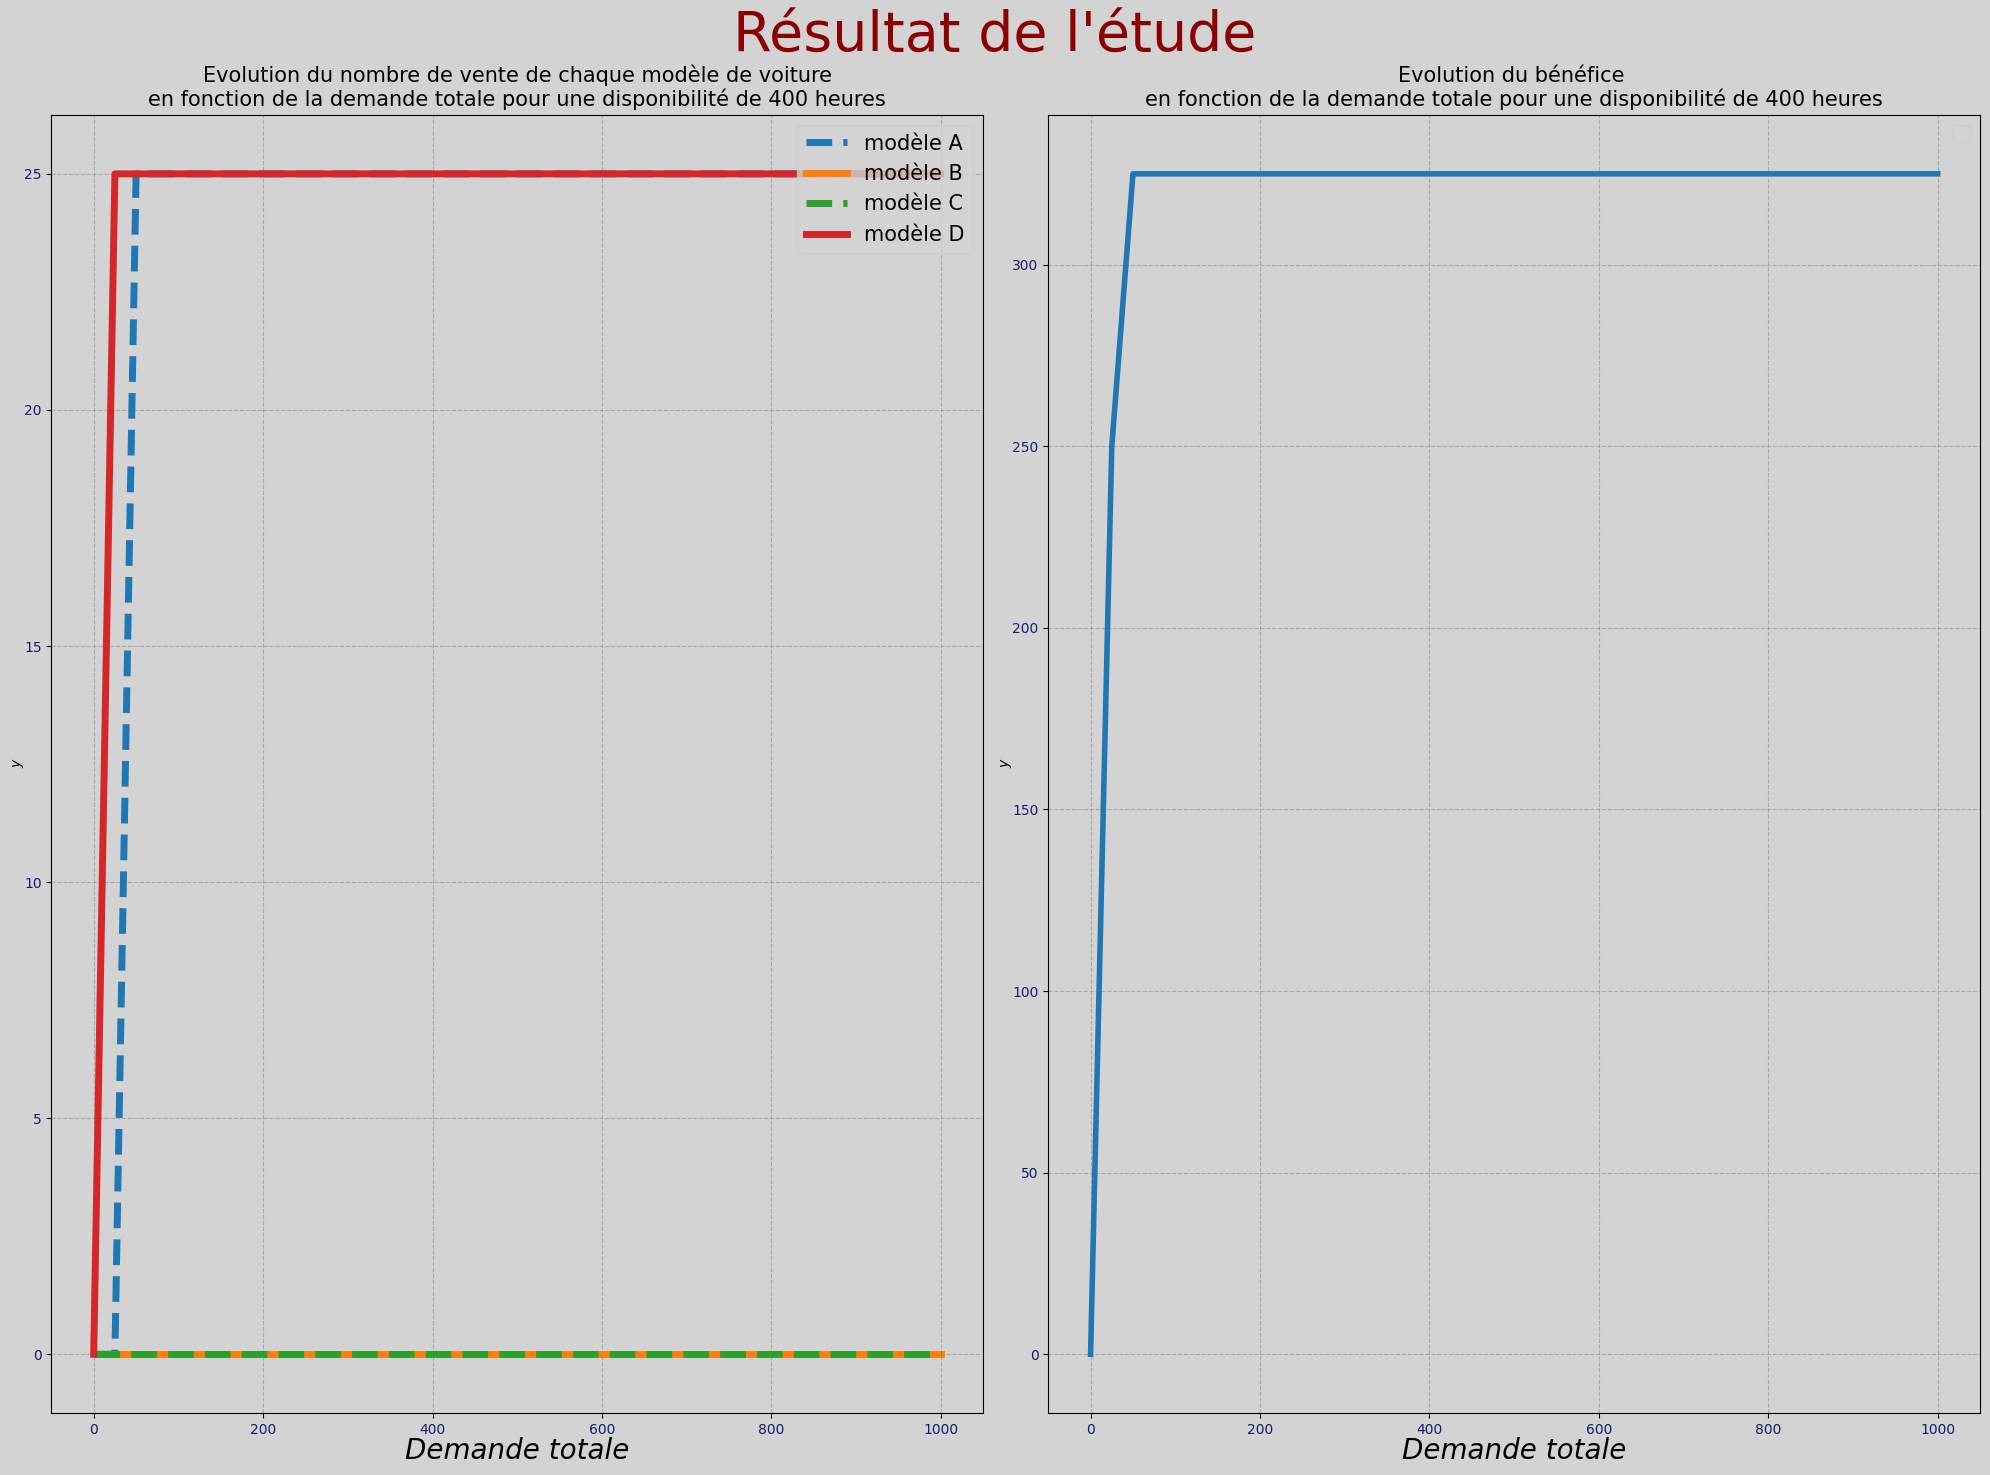

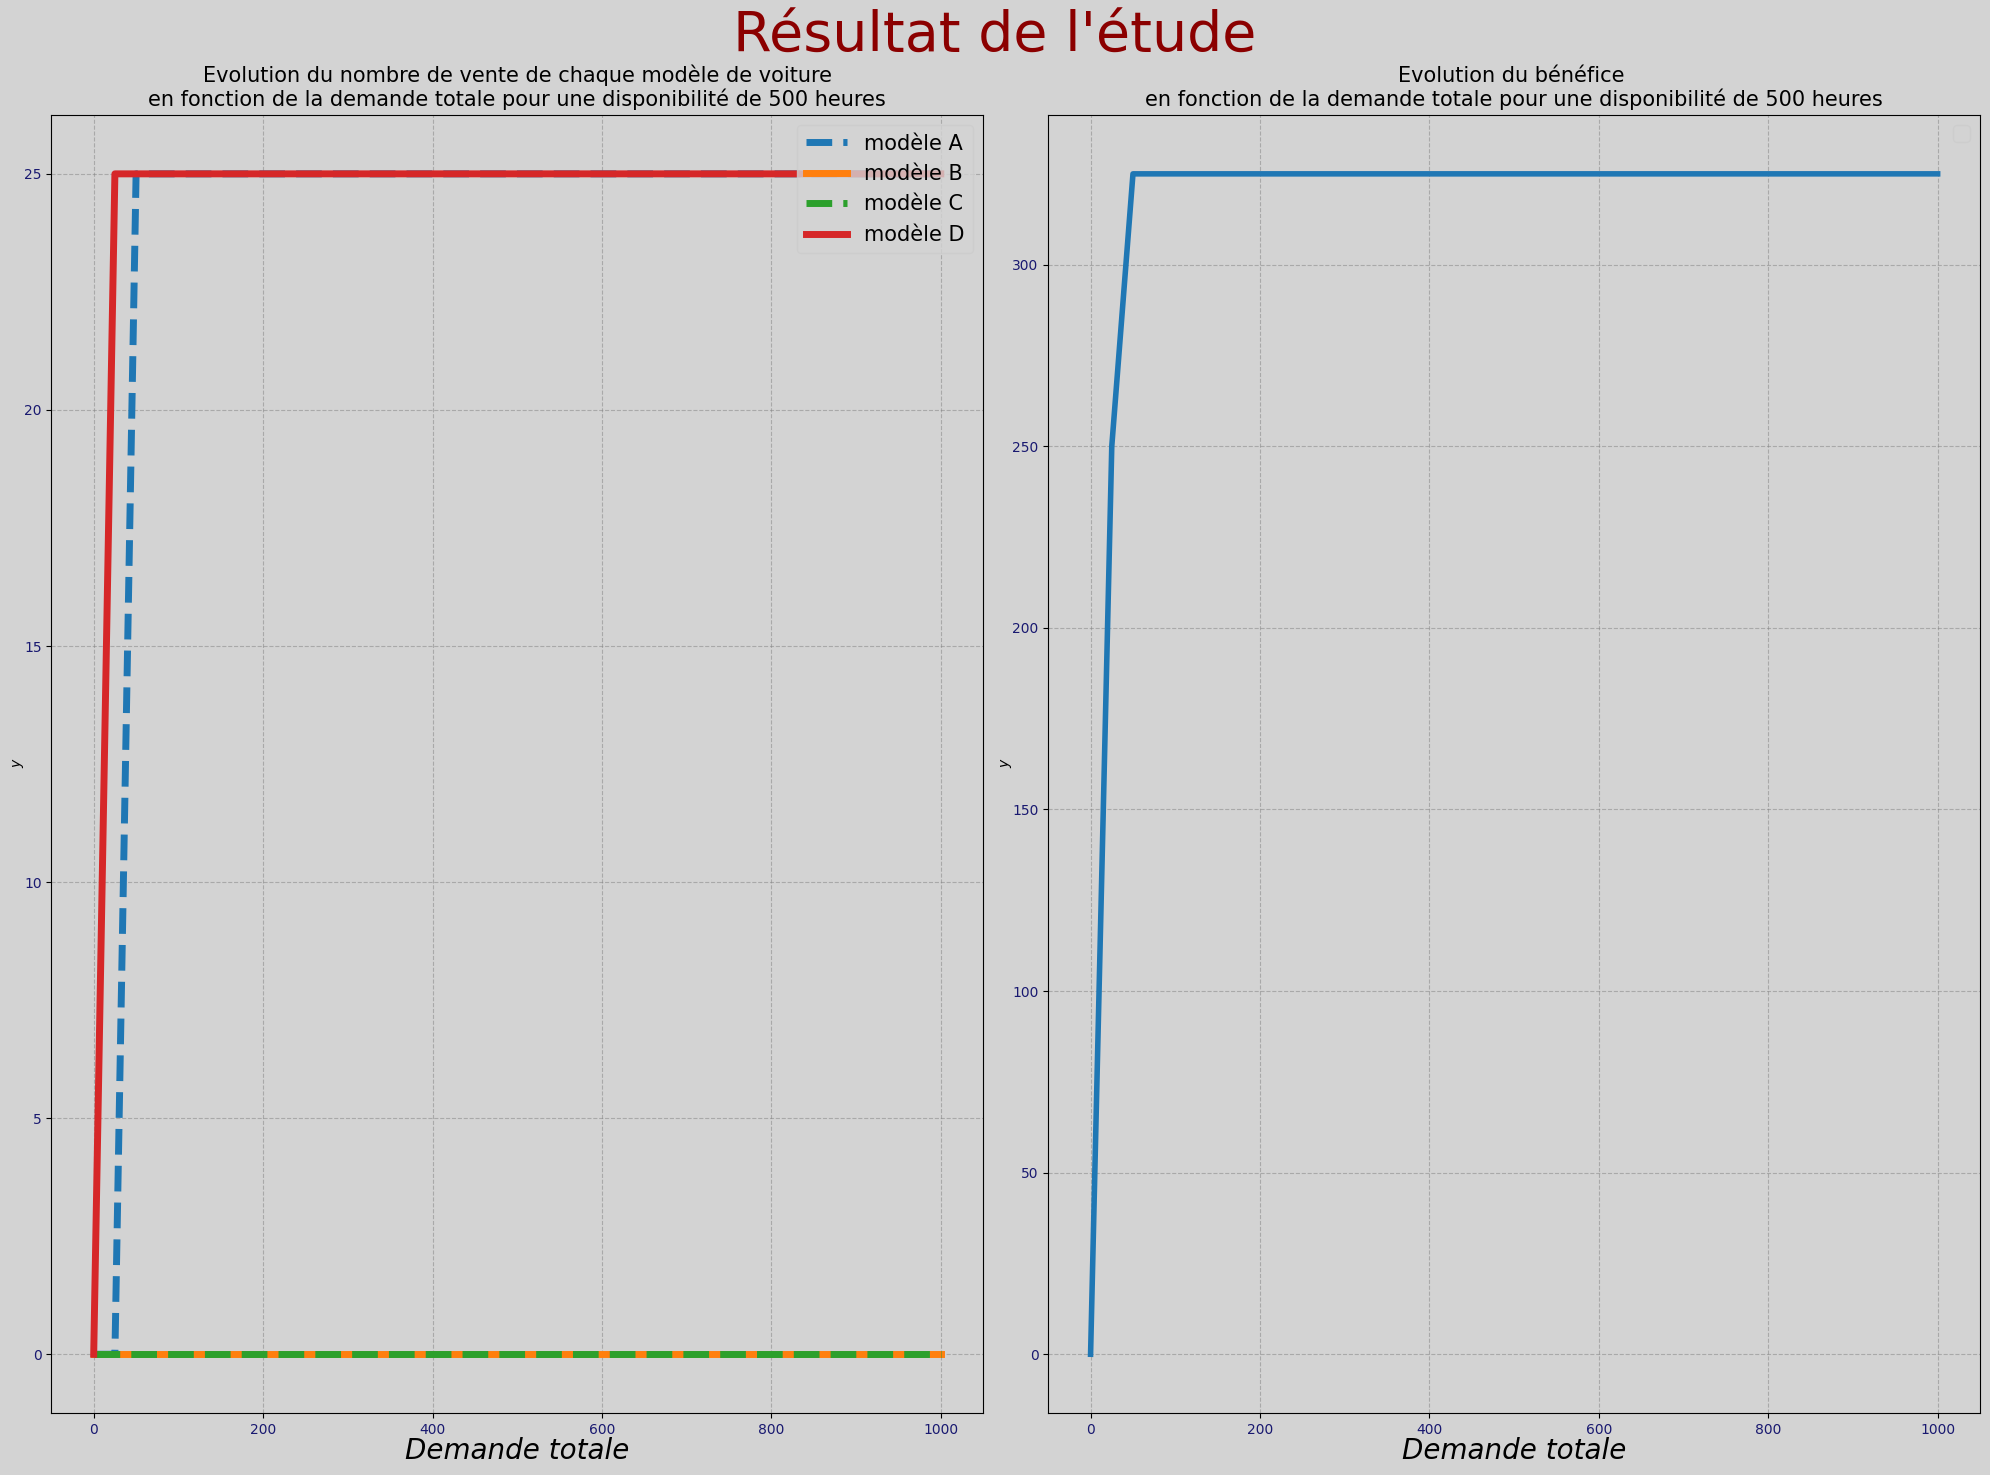

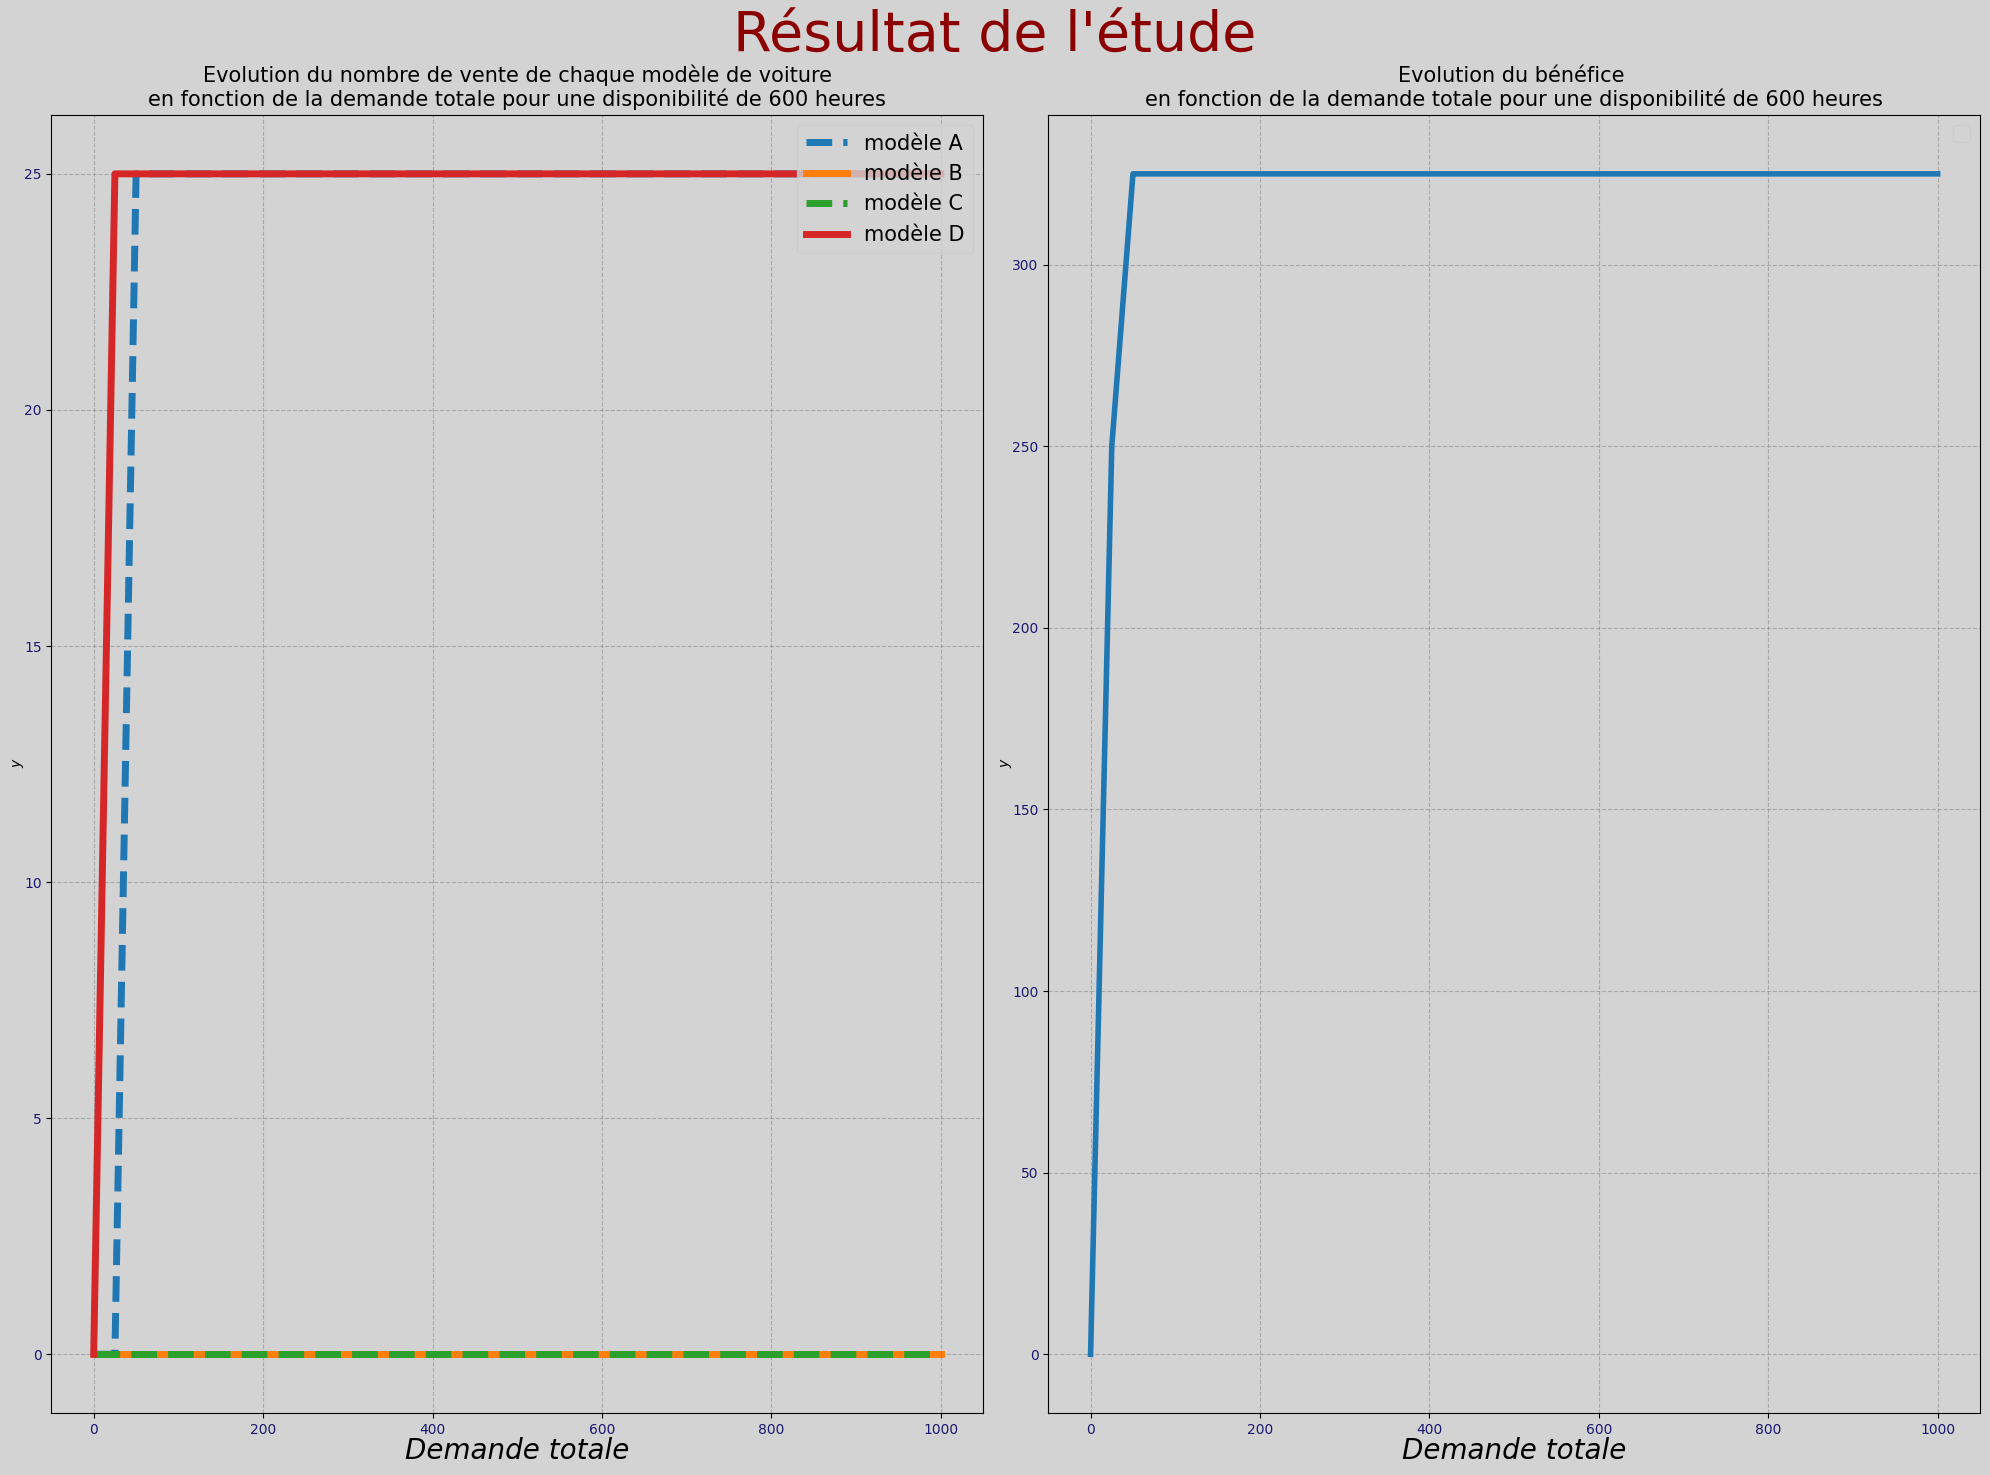

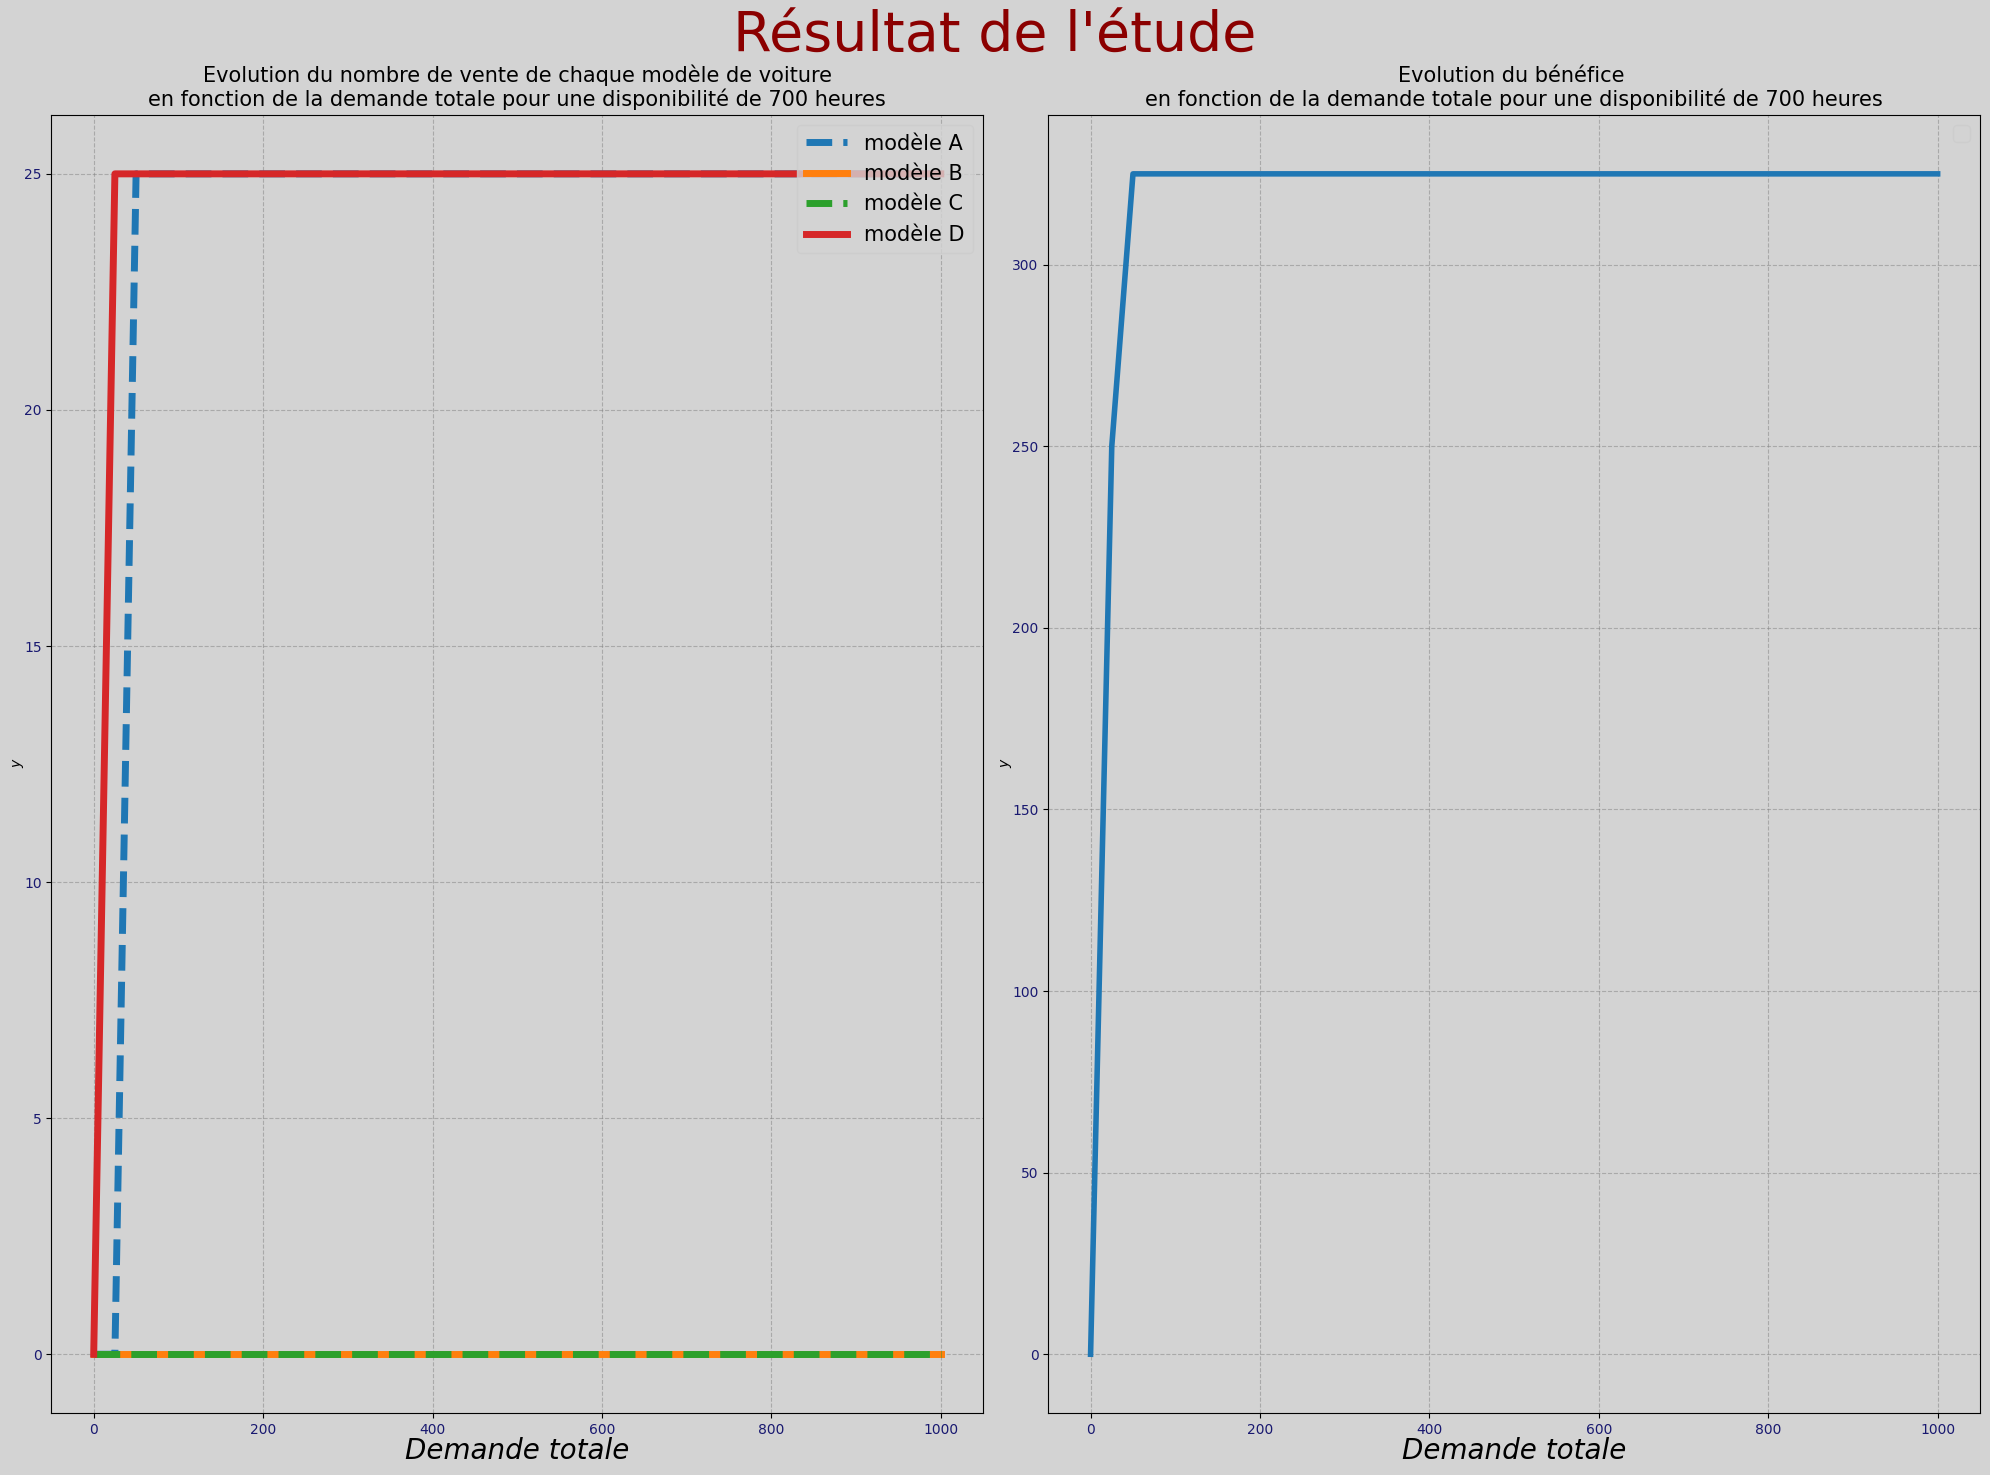

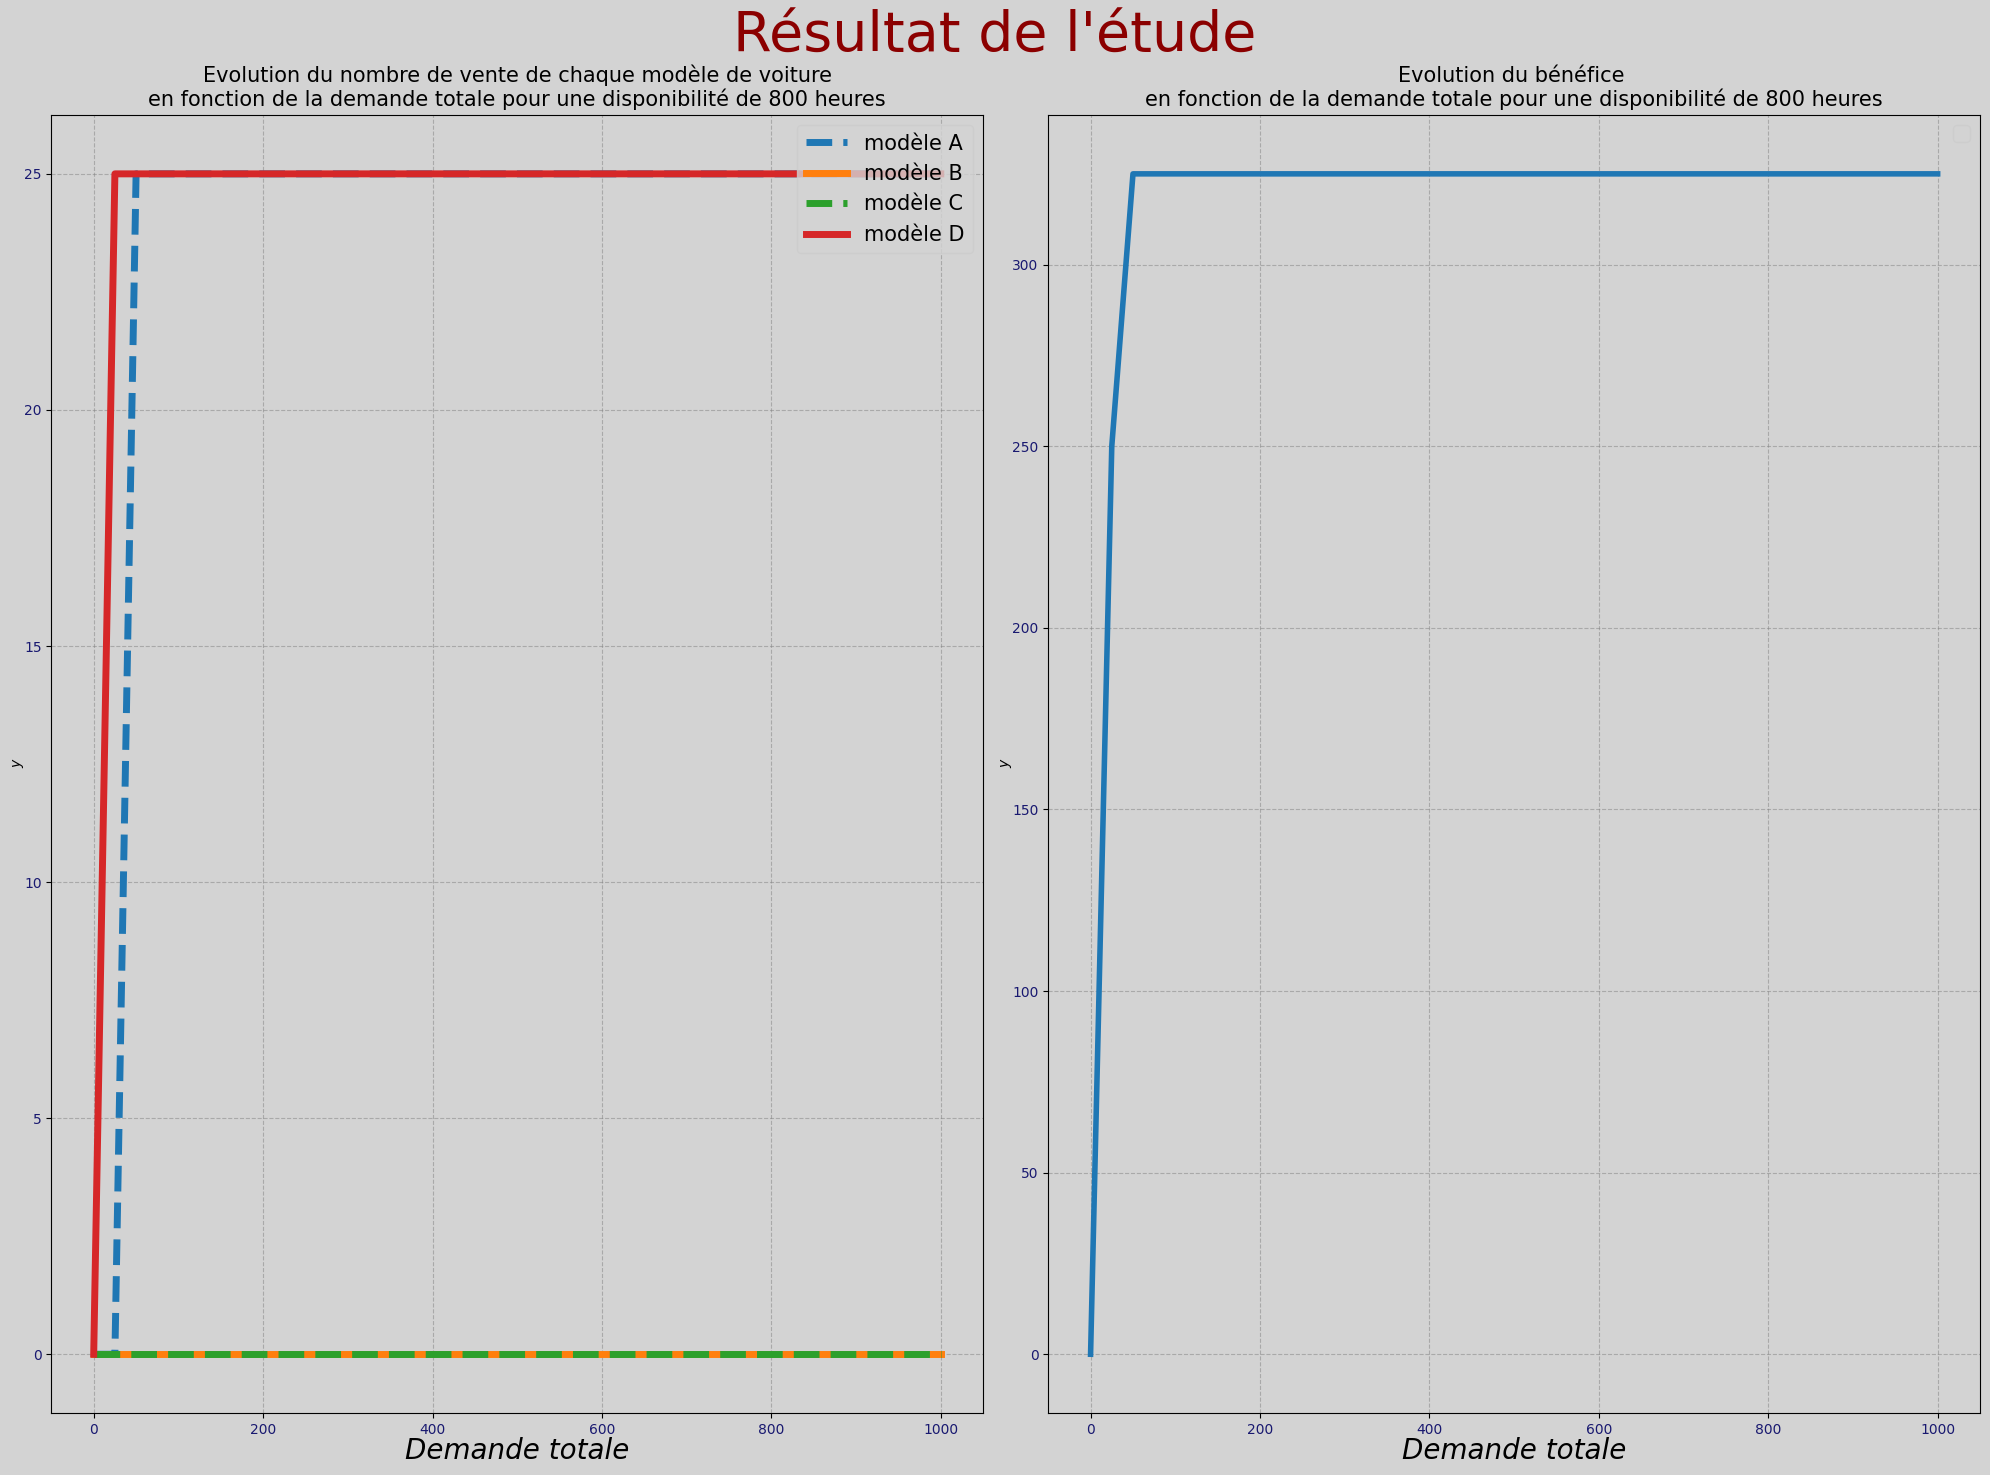

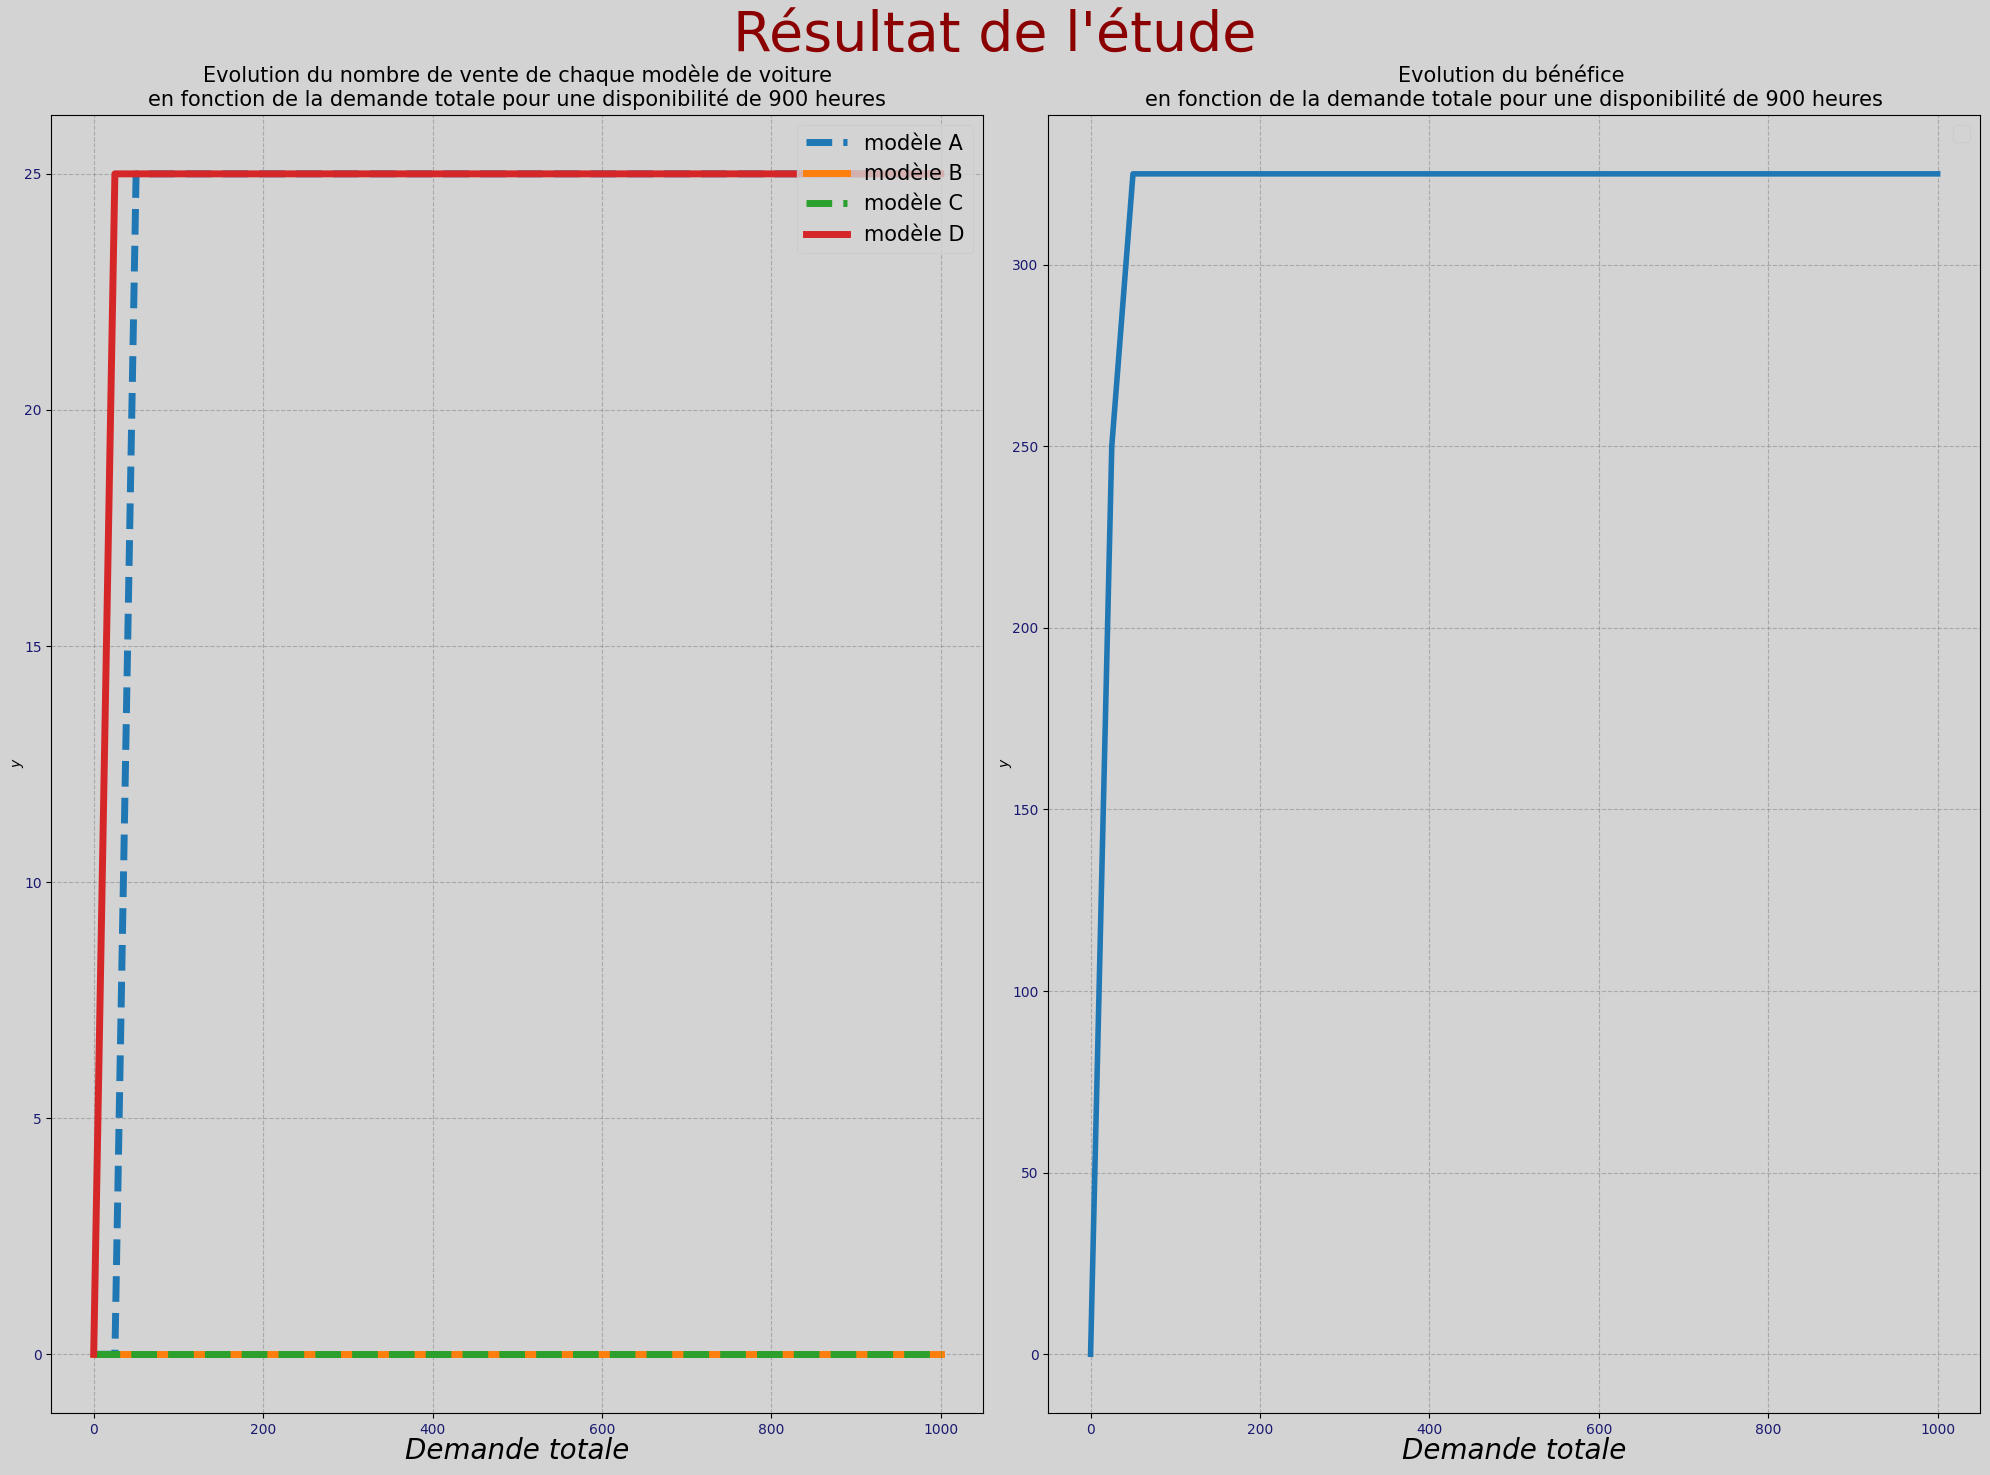

In [41]:
Fonction = [-3,-2,-5,-10]

bound = 2*[(0,100)]+[(0,None)]+[(0,None)]



for dispo in [d for d in range(100,1000,100)]:
    X_sol_A=[]
    X_sol_B=[]
    X_sol_C=[]
    X_sol_D=[]
    f_max = []
    for demande_tot in [d for d in range(0,1000)]:

        coef_contrainte = np.array([[2,1,5,8],
                                [1,1,1,1],
                                [0,0,1,1],
                                [2,1,4,2],
                                [0.2,0.2,0.5,1],
                                [1,1,2,2],
                                [2,2,1,2],
                                [1,1,1.5,0.8],
                                [0,0,2,2],
                                [1,1,1,1.2],
                                [2,2,1,1],
                                [0,0,1,1]])

        Second_membre = np.array([dispo,demande_tot,30,125,55,300,100,60,50,100,220,30])

        result = so.linprog(Fonction,coef_contrainte,Second_membre,bounds=bound)
        if result.success:
            f_max.append(round(-result.fun))
            X_sol_A.append(result.x[0])
            X_sol_B.append(result.x[1])
            X_sol_C.append(result.x[2])
            X_sol_D.append(result.x[3])

        
    x_graph = np.linspace(0,1000,1000)


    fig,ax = plt.subplots(ncols=2,nrows=1,figsize = (20,15))

    ax[0].plot(x_graph,np.array(X_sol_A),linestyle = '--',lw=5,label ='modèle A')
    ax[0].plot(x_graph,np.array(X_sol_B),lw=5,label = 'modèle B')
    ax[0].plot(x_graph,np.array(X_sol_C),linestyle = '--',lw=5,label = 'modèle C')
    ax[0].plot(x_graph,np.array(X_sol_D),lw=5,label = 'modèle D')
    ax[0].set_title(f"Evolution du nombre de vente de chaque modèle de voiture\nen fonction de la demande totale pour une disponibilité de {dispo} heures",size =15)

    ax[1].plot(x_graph,f_max,lw=4)
    ax[1].set_title(f'Evolution du bénéfice \nen fonction de la demande totale pour une disponibilité de {dispo} heures',size = 15)

    mon_theme(fig,ax,ncols=2,nrows=1,show_grid=True,show_legende_a_droite=False,
            loc_si_legende_interieure='upper right',
            xlabel='Demande totale',
            titre="Résultat de l'étude",
            legend_fontsize=15,xlabelsize=20,titre_fontsize=40,
            marge_droite_graph=1)


Il y a donc plusieurs choses à noter:

- Le modèle C n'est jamais vendu par l'entreprise et ceux pour n'importe quelle demande totale et disponibilité de la machine
  
- Les contraintes en matières premières sont très contraignantes pour l'entreprise qui ne peut pas se permettre de vendre trop de voiture à cause de ses stocks limités, ainsi peu importe la demande, l'entreprise ne peut pas vendre plus de 50 véhicules (ce qui est une conséquence du stock en acier)
  
- Lorsque la disponibilité de la machine est inférieure à 200 heures alors l'entreprise ne vend que les modèles D et B sinon, elle ne vend que les voitures A et D
  
- Si la demande est faible et la disponibilité de la machine est inférieure à 200 heures, alors l'entreprise vendra plus de modèle B que de modèle D, si la demande est assez grande alors elle vendra plus de modèle D

- Lorsque que la demande est supérieur à une certaine valeur, l'entreprise gardera les mêmes niveaux de production peu importe la demande totale, ceci est encore une fois du à ses contraintes en matières premières.